In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import json
import random
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from transformer_lens import HookedTransformer, utils
import circuitsvis as cv

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
HENDEL_REPO = Path("/home/cvllab/Documents/andrew/repos/icl_task_vectors")
MODEL_NAME = "meta-llama/Llama-3.2-3B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

N_DEMOS = 10          # demonstrations per ICL prompt
N_TV_PROMPTS = 50     # prompts averaged to form θ_L (Hendel uses 50, see t-SNE Fig 5)
N_EVAL_QUERIES = 20   # held-out queries for patching accuracy

random.seed(42)
torch.manual_seed(42)

Device: cuda


## 1. Load Model

In [4]:
print(f"Loading {MODEL_NAME}...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
model.eval()
tokenizer = model.tokenizer
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
print(f"{n_layers} layers, {n_heads} heads, d_model={d_model}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.2-3B...


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
28 layers, 24 heads, d_model=3072


## 2. Load Task Data

In [5]:
def parse_json_pairs(content):
    """Try multiple formats to extract (input, output) pairs from JSON."""
    if not isinstance(content, (list, dict)):
        return None
    if isinstance(content, list) and len(content) > 0:
        if isinstance(content[0], (list, tuple)) and len(content[0]) == 2:
            return [(str(x), str(y)) for x, y in content]
        if isinstance(content[0], dict):
            for k_in, k_out in [('input','output'),('x','y'),('source','target'),
                                ('word','translation'),('question','answer')]:
                if k_in in content[0] and k_out in content[0]:
                    return [(str(d[k_in]), str(d[k_out])) for d in content]
            str_keys = [k for k,v in content[0].items() if isinstance(v,str)]
            if len(str_keys) >= 2:
                return [(str(d[str_keys[0]]), str(d[str_keys[1]])) for d in content]
    if isinstance(content, dict):
        return [(str(k), str(v)) for k, v in content.items()]
    return None

def load_hendel_data(repo_path):
    data_dir = repo_path / "data"
    tasks = {}
    if not data_dir.exists():
        return tasks
    for json_file in sorted(data_dir.rglob("*.json")):
        task_name = str(json_file.relative_to(data_dir).with_suffix(''))
        try:
            with open(json_file) as f:
                content = json.load(f)
        except Exception:
            continue
        pairs = parse_json_pairs(content)
        if pairs and len(pairs) > 0:
            tasks[task_name] = pairs
    return tasks

tasks = load_hendel_data(HENDEL_REPO)
print(f"Loaded {len(tasks)} tasks from Hendel repo.")

for name, pairs in tasks.items():
    print(f"  {name}: {len(pairs)} pairs, e.g. {pairs[0]}")

Loaded 20 tasks from Hendel repo.
  knowledge/country_capital: 139 pairs, e.g. ('Al Madinah Region', 'Medina')
  knowledge/football_player_position: 952 pairs, e.g. ('Percy Snow', 'linebacker')
  knowledge/location_continent: 957 pairs, e.g. ('Pidgeon Island', 'Antarctica')
  knowledge/location_country: 714 pairs, e.g. ('Galata', 'Istanbul')
  knowledge/location_language: 737 pairs, e.g. ('Northwest Territories', 'English')
  knowledge/location_religion: 368 pairs, e.g. ('Edwin of Northumbria', 'Christian')
  knowledge/person_language: 923 pairs, e.g. ('Gilad Atzmon', 'Hebrew')
  knowledge/person_profession: 821 pairs, e.g. ('Billy Roche', 'actor')
  linguistic/antonyms: 162 pairs, e.g. ('high', 'low')
  linguistic/plural_singular: 172 pairs, e.g. ('addenda', 'addendum')
  linguistic/present_simple_gerund: 1008 pairs, e.g. ('acknowledge', 'acknowledging')
  linguistic/present_simple_past_perfect: 110 pairs, e.g. ('awake', 'awoken')
  linguistic/present_simple_past_simple: 1005 pairs, e

## 3. Prompt Construction

In [6]:
# Format: `input1 → output1\ninput2 → output2\n...\nquery →`

SEPARATOR = " →"
DEMO_SEP = "\n"

def build_icl_prompt(demo_pairs, query_input):
    """Build: inp1 → out1\ninp2 → out2\n...\nquery →"""
    lines = [f"{inp}{SEPARATOR} {out}" for inp, out in demo_pairs]
    lines.append(f"{query_input}{SEPARATOR}")
    return DEMO_SEP.join(lines)

def build_zero_shot_prompt(query_input):
    """Build: query →"""
    return f"{query_input}{SEPARATOR}"

def get_last_token_pos(model, prompt):
    """Return index of the last token in the prompt."""
    tokens = model.to_tokens(prompt, prepend_bos=True)
    return tokens.shape[1] - 1

def find_role_positions(model, prompt, demo_pairs, query_input):
    """Find which token positions correspond to input words vs output words."""
    input_pos = []
    output_pos = []
    current_text = ""
    for inp, out in demo_pairs:
        prefix_len = len(model.to_tokens(current_text, prepend_bos=True)[0]) if current_text else 1
        
        # Input tokens
        with_input = current_text + inp
        with_input_len = len(model.to_tokens(with_input, prepend_bos=True)[0])
        input_pos.extend(range(prefix_len, with_input_len))
        
        # Skip separator
        with_sep = with_input + SEPARATOR
        with_sep_len = len(model.to_tokens(with_sep, prepend_bos=True)[0])
        
        # Output tokens
        with_output = with_sep + " " + out
        with_output_len = len(model.to_tokens(with_output, prepend_bos=True)[0])
        output_pos.extend(range(with_sep_len, with_output_len))
        
        current_text = with_output + DEMO_SEP
    
    return {'input_positions': input_pos, 'output_positions': output_pos}

# Quick sanity check
test_prompt = build_icl_prompt([("France", "Paris"), ("Germany", "Berlin")], "Japan")
print(f"Test prompt: {repr(test_prompt)}")
print(f"Tokens: {model.to_str_tokens(test_prompt, prepend_bos=True)}")
print(f"Last token pos: {get_last_token_pos(model, test_prompt)}")

Test prompt: 'France → Paris\nGermany → Berlin\nJapan →'
Tokens: ['<|begin_of_text|>', 'France', ' →', ' Paris', '\n', 'Germany', ' →', ' Berlin', '\n', 'Japan', ' →']
Last token pos: 10


## 4. Sample Data for Each Task

In [7]:
# For each task we need:
# - **N_TV_PROMPTS** ICL prompts (different demo sets, different queries) → averaged to form $\theta_L$
# - **N_EVAL_QUERIES** held-out queries → used to measure patching accuracy

# Each prompt uses N_DEMOS demonstrations sampled without replacement.

def sample_task_splits(pairs, n_demos, n_tv_prompts, n_eval):
    """Create TV prompts and eval queries for one task.
    
    Each TV prompt: random subset of n_demos pairs as demos, random query.
    Eval queries: separate held-out (input, output) pairs.
    """
    all_pairs = list(pairs)
    
    tv_prompts = []
    for _ in range(n_tv_prompts):
        sampled = random.sample(all_pairs, min(n_demos + 1, len(all_pairs)))
        demos = sampled[:n_demos]
        query_in, query_out = sampled[n_demos]
        prompt_str = build_icl_prompt(demos, query_in)
        tv_prompts.append({
            'prompt': prompt_str,
            'demo_pairs': demos,
            'query_input': query_in,
            'query_output': query_out,
        })
    
    # Eval queries: sample separate prompts with different demo sets
    eval_data = []
    for _ in range(n_eval):
        sampled = random.sample(all_pairs, min(n_demos + 1, len(all_pairs)))
        demos = sampled[:n_demos]
        query_in, query_out = sampled[n_demos]
        eval_data.append({
            'demo_pairs': demos,
            'query_input': query_in,
            'query_output': query_out,
            'icl_prompt': build_icl_prompt(demos, query_in),
            'zs_prompt': build_zero_shot_prompt(query_in),
        })
    
    return tv_prompts, eval_data

all_task_splits = {}
for task_name, pairs in tasks.items():
    tv_prompts, eval_data = sample_task_splits(pairs, N_DEMOS, N_TV_PROMPTS, N_EVAL_QUERIES)
    all_task_splits[task_name] = {'tv_prompts': tv_prompts, 'eval_data': eval_data}
    print(f"{task_name}: {len(tv_prompts)} TV prompts, {len(eval_data)} eval queries")

knowledge/country_capital: 50 TV prompts, 20 eval queries
knowledge/football_player_position: 50 TV prompts, 20 eval queries
knowledge/location_continent: 50 TV prompts, 20 eval queries
knowledge/location_country: 50 TV prompts, 20 eval queries
knowledge/location_language: 50 TV prompts, 20 eval queries
knowledge/location_religion: 50 TV prompts, 20 eval queries
knowledge/person_language: 50 TV prompts, 20 eval queries
knowledge/person_profession: 50 TV prompts, 20 eval queries
linguistic/antonyms: 50 TV prompts, 20 eval queries
linguistic/plural_singular: 50 TV prompts, 20 eval queries
linguistic/present_simple_gerund: 50 TV prompts, 20 eval queries
linguistic/present_simple_past_perfect: 50 TV prompts, 20 eval queries
linguistic/present_simple_past_simple: 50 TV prompts, 20 eval queries
linguistic/singular_plural: 50 TV prompts, 20 eval queries
translation/en_es: 50 TV prompts, 20 eval queries
translation/en_fr: 50 TV prompts, 20 eval queries
translation/en_it: 50 TV prompts, 20 eval

## 5. Extract Final Position

In [8]:
# $\theta_L = \frac{1}{N}\sum_i h^{(L)}_{i,\text{last}}$

# For each task, run all N_TV_PROMPTS through the model.
# At each layer $L$, collect the residual stream at the last token position.
# Average across prompts → $\theta_L$.

# We also collect the mean hidden states at input/output positions for the
# diff-means decomposition.

RESID_FILTER = lambda name: "resid_post" in name

# Storage: task_name -> layer -> list of vectors (one per prompt)
last_token_vecs = defaultdict(lambda: defaultdict(list))  # h^(L)_{last}
mean_input_vecs = defaultdict(lambda: defaultdict(list))   # mean h^(L) at input positions
mean_output_vecs = defaultdict(lambda: defaultdict(list))  # mean h^(L) at output positions

for task_name, splits in all_task_splits.items():
    print(f"\nExtracting: {task_name} ({len(splits['tv_prompts'])} prompts)")
    
    for pdata in tqdm(splits['tv_prompts'], desc=f"  {task_name}"):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        
        # Find input/output positions for diff-means
        roles = find_role_positions(model, prompt, pdata['demo_pairs'], pdata['query_input'])
        
        for layer in range(n_layers):
            h = cache['resid_post', layer][0].cpu().float()  # (seq_len, d_model)
            
            # Last token hidden state
            last_token_vecs[task_name][layer].append(h[last_pos].numpy())
            
            # Mean input / output hidden states
            if roles['input_positions']:
                mean_input_vecs[task_name][layer].append(
                    h[roles['input_positions']].mean(0).numpy()
                )
            if roles['output_positions']:
                mean_output_vecs[task_name][layer].append(
                    h[roles['output_positions']].mean(0).numpy()
                )
        
        del cache
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

print("\nDone extracting.")


Extracting: knowledge/country_capital (50 prompts)


  knowledge/country_capital: 100%|██████████| 50/50 [00:03<00:00, 14.89it/s]



Extracting: knowledge/football_player_position (50 prompts)


  knowledge/football_player_position: 100%|██████████| 50/50 [00:03<00:00, 15.35it/s]



Extracting: knowledge/location_continent (50 prompts)


...


Extracting: translation/fr_en (50 prompts)


  translation/fr_en: 100%|██████████| 50/50 [00:03<00:00, 15.38it/s]



Extracting: translation/it_en (50 prompts)


  translation/it_en: 100%|██████████| 50/50 [00:03<00:00, 14.74it/s]


Done extracting.


In [ ]:
# Compute task vectors: θ_L = mean across prompts of last-token hidden state
# Also compute mean-of-means for input and output positions

task_vectors = {}   # task_name -> layer -> θ_L (numpy array, shape d_model)
mean_inputs = {}    # task_name -> layer -> mean input vec
mean_outputs = {}   # task_name -> layer -> mean output vec

for task_name in last_token_vecs:
    task_vectors[task_name] = {}
    mean_inputs[task_name] = {}
    mean_outputs[task_name] = {}
    for layer in range(n_layers):
        vecs = last_token_vecs[task_name][layer]
        task_vectors[task_name][layer] = np.mean(vecs, axis=0)
        
        if mean_input_vecs[task_name][layer]:
            mean_inputs[task_name][layer] = np.mean(mean_input_vecs[task_name][layer], axis=0)
        if mean_output_vecs[task_name][layer]:
            mean_outputs[task_name][layer] = np.mean(mean_output_vecs[task_name][layer], axis=0)

print(f"Task vectors computed for {len(task_vectors)} tasks × {n_layers} layers.")
print(f"θ shape: {task_vectors[list(task_vectors.keys())[0]][0].shape}")

Task vectors computed for 20 tasks × 28 layers.
θ shape: (3072,)


## 6. Replicate Hendel et al. Figure 3

In [10]:
# For each (task, layer $L$, eval query):
# 1. Run zero-shot prompt `query →`
# 2. At layer $L$, replace the last-token residual with $\theta_L$
# 3. Check if the model's prediction matches the target

# Also measure regular ICL accuracy and zero-shot baseline.

def check_correct(model, pred_logits, target_output):
    """Check if top-1 prediction matches target (first token)."""
    pred_id = pred_logits.argmax().item()
    pred_str = model.tokenizer.decode([pred_id]).strip().lower()
    target_str = target_output.strip().lower()
    # First-token match
    target_tokens = model.tokenizer.encode(" " + target_output)
    if target_tokens and pred_id == target_tokens[0]:
        return True
    # String prefix match
    if pred_str and target_str and (pred_str.startswith(target_str[:3]) or target_str.startswith(pred_str[:3])):
        return True
    return False


@torch.no_grad()
def eval_patched(model, zs_prompt, theta, layer):
    """Run zero-shot prompt, patch last-token residual at layer L with θ."""
    tokens = model.to_tokens(zs_prompt, prepend_bos=True)
    last_pos = tokens.shape[1] - 1
    theta_tensor = torch.tensor(theta, device=DEVICE, dtype=model.cfg.dtype)
    
    def patch_hook(value, hook):
        value[0, last_pos, :] = theta_tensor
        return value
    
    logits = model.run_with_hooks(
        tokens,
        fwd_hooks=[(f'blocks.{layer}.hook_resid_post', patch_hook)]
    )
    return logits[0, -1]  # last-position logits

In [11]:
# Run patching experiment across all tasks and layers

patching_acc = defaultdict(lambda: defaultdict(list))  # task -> layer -> [bool]
icl_acc = defaultdict(list)      # task -> [bool]
zs_acc = defaultdict(list)       # task -> [bool]

for task_name, splits in all_task_splits.items():
    print(f"\nEvaluating: {task_name}")
    
    for edata in tqdm(splits['eval_data'], desc=f"  {task_name}"):
        target = edata['query_output']
        
        # Regular ICL
        with torch.no_grad():
            icl_tokens = model.to_tokens(edata['icl_prompt'], prepend_bos=True)
            icl_logits = model(icl_tokens)[0, -1]
        icl_acc[task_name].append(check_correct(model, icl_logits, target))
        
        # Zero-shot
        with torch.no_grad():
            zs_tokens = model.to_tokens(edata['zs_prompt'], prepend_bos=True)
            zs_logits = model(zs_tokens)[0, -1]
        zs_acc[task_name].append(check_correct(model, zs_logits, target))
        
        # Patching at each layer
        for layer in range(n_layers):
            theta = task_vectors[task_name][layer]
            patched_logits = eval_patched(model, edata['zs_prompt'], theta, layer)
            patching_acc[task_name][layer].append(
                check_correct(model, patched_logits, target)
            )
        
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

print("\nDone.")


Evaluating: knowledge/country_capital


  knowledge/country_capital: 100%|██████████| 20/20 [00:23<00:00,  1.19s/it]



Evaluating: knowledge/football_player_position


  knowledge/football_player_position: 100%|██████████| 20/20 [00:23<00:00,  1.19s/it]



Evaluating: knowledge/location_continent


...


Evaluating: translation/fr_en


  translation/fr_en: 100%|██████████| 20/20 [00:23<00:00,  1.20s/it]



Evaluating: translation/it_en


  translation/it_en: 100%|██████████| 20/20 [00:23<00:00,  1.19s/it]


Done.


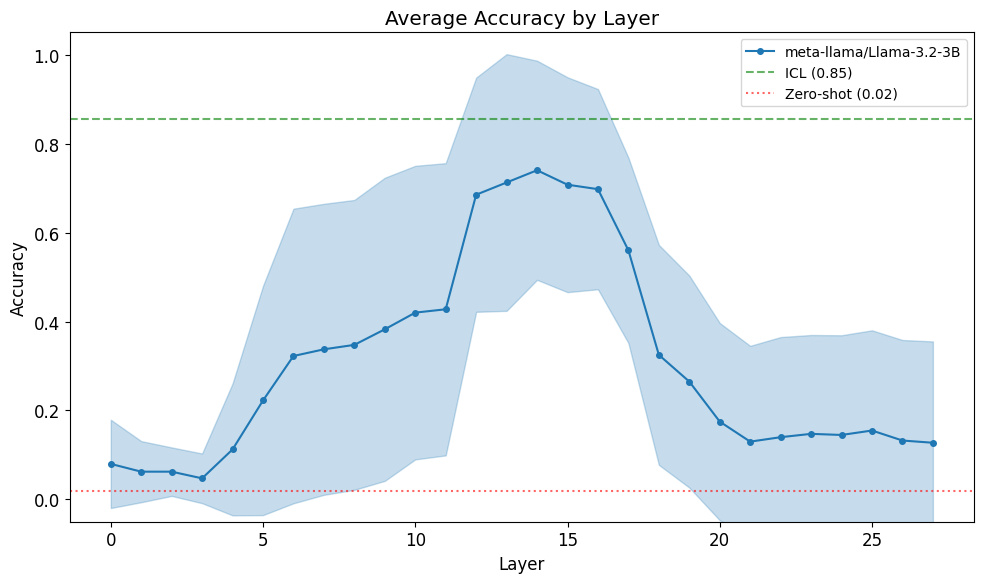

Best patching layer: 14 (acc=0.740)
ICL accuracy: 0.855
Recovery: 87%
Tasks used: 20


In [12]:
layers = list(range(n_layers))
all_tn = list(all_task_splits.keys())
acc_matrix = np.array([[np.mean(patching_acc[tn][l]) for l in layers] for tn in all_tn])
mean_acc = acc_matrix.mean(axis=0)
std_acc = acc_matrix.std(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(layers, mean_acc, 'o-', ms=4, color='tab:blue', label=f'{MODEL_NAME}')
ax.fill_between(layers, mean_acc - std_acc, mean_acc + std_acc, alpha=0.25, color='tab:blue')

avg_icl = np.mean([np.mean(icl_acc[tn]) for tn in all_tn])
avg_zs = np.mean([np.mean(zs_acc[tn]) for tn in all_tn])
ax.axhline(avg_icl, ls='--', color='green', alpha=0.6, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.6, label=f'Zero-shot ({avg_zs:.2f})')

ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('Average Accuracy by Layer')
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('fig3_accuracy_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()

best_layer = layers[np.argmax(mean_acc)]
print(f"Best patching layer: {best_layer} (acc={mean_acc.max():.3f})")
print(f"ICL accuracy: {avg_icl:.3f}")
print(f"Recovery: {mean_acc.max() / max(avg_icl, 0.01):.0%}")
print(f"Tasks used: {len(all_tn)}")


In [13]:
# Table 3: Top tokens in task vector vocab projection

table3_data = {}
for task_name in task_vectors:
    # Use best patching layer for this task
    accs = {l: np.mean(patching_acc[task_name][l]) for l in layers}
    best_l = max(accs, key=accs.get)
    
    theta = task_vectors[task_name][best_l]
    theta_t = torch.tensor(theta, device=DEVICE, dtype=model.cfg.dtype).unsqueeze(0).unsqueeze(0)
    
    with torch.no_grad():
        logits = model.unembed(theta_t)  # (1, 1, vocab_size)
    probs = torch.softmax(logits[0, 0].float(), dim=-1)
    top_vals, top_ids = probs.topk(10)
    top_tokens = [model.tokenizer.decode([tid.item()]).strip() for tid in top_ids]
    table3_data[task_name] = (best_l, top_tokens, top_vals.cpu().numpy())
    
    print(f"\n{task_name} (layer {best_l}, patching acc={accs[best_l]:.2f}):")
    print(f"  Top tokens: {', '.join(top_tokens)}")


knowledge/country_capital (layer 13, patching acc=0.85):
  Top tokens: eum, squ, /from, 布, olest, ADING, ROC, ipt, 输, quiv

knowledge/football_player_position (layer 17, patching acc=0.40):
  Top tokens: forwards, forward, midfielder, assistant, goalt, outfield, scorer, utility, miscellaneous, striker

knowledge/location_continent (layer 14, patching acc=0.55):
  Top tokens: pter, pert, Tây, -INF, Plantae, DESC, PIO, istan, isto, rama

knowledge/location_country (layer 12, patching acc=0.65):
  Top tokens: pert, ix, bunk, orts, void, jis, čka, orth, react, parlament

knowledge/location_language (layer 12, patching acc=0.90):
  Top tokens: ix, pert, domic, react, orth, tier, iid, kon, ETO, alim

knowledge/location_religion (layer 17, patching acc=0.90):
  Top tokens: Judaism, Religion, Islam, atheist, Religious, religious, Muslim, Christianity, relig, martyr

knowledge/person_language (layer 12, patching acc=0.80):
  Top tokens: pert, domic, biography, ix, react, maybe, orth, nel, alim

## 8. Diffmeans Decomposition

In [14]:
# Test: $\theta_L \approx a \cdot \bar{h}_{\text{out}} + b \cdot \bar{h}_{\text{in}}$ with $a \approx -b$?
# We solve the OLS problem treating the $d_{\text{model}}$ dimensions as observations:
# $$\min_{a,b} \| \theta_L - a \cdot \bar{h}_{\text{out}} - b \cdot \bar{h}_{\text{in}} \|^2$$

def fit_diffmeans(h_last, mean_in, mean_out):
    """OLS: h_last ≈ a·mean_out + b·mean_in. Returns dict of metrics."""
    X = np.stack([mean_out, mean_in], axis=1)  # (d_model, 2)
    coeffs, _, _, _ = np.linalg.lstsq(X, h_last, rcond=None)
    a, b = coeffs[0], coeffs[1]
    resid = h_last - X @ coeffs
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((h_last - h_last.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
    denom = abs(a) + abs(b)
    dm_score = abs(a + b) / denom if denom > 1e-12 else float('inf')
    return {'a': a, 'b': b, 'r_squared': r2, 'diffmeans_score': dm_score}


# Per-prompt decomposition: for each prompt i, fit h^(L)_{i,last} ≈ a_i·mean_out_i + b_i·mean_in_i
# decomp_per_prompt[task][layer] = list of result dicts, one per prompt
decomp_per_prompt = defaultdict(lambda: defaultdict(list))

for task_name in last_token_vecs:
    for layer in range(n_layers):
        h_lasts = last_token_vecs[task_name][layer]
        m_ins = mean_input_vecs[task_name][layer]
        m_outs = mean_output_vecs[task_name][layer]
        for i in range(len(h_lasts)):
            if i < len(m_ins) and i < len(m_outs):
                result = fit_diffmeans(h_lasts[i], m_ins[i], m_outs[i])
                decomp_per_prompt[task_name][layer].append(result)

print(f"Per-prompt decomposition: {len(decomp_per_prompt)} tasks")
ex_task = list(decomp_per_prompt.keys())[0]
print(f"  {ex_task}, layer 0: {len(decomp_per_prompt[ex_task][0])} prompts")

Per-prompt decomposition: 20 tasks
  knowledge/country_capital, layer 0: 50 prompts


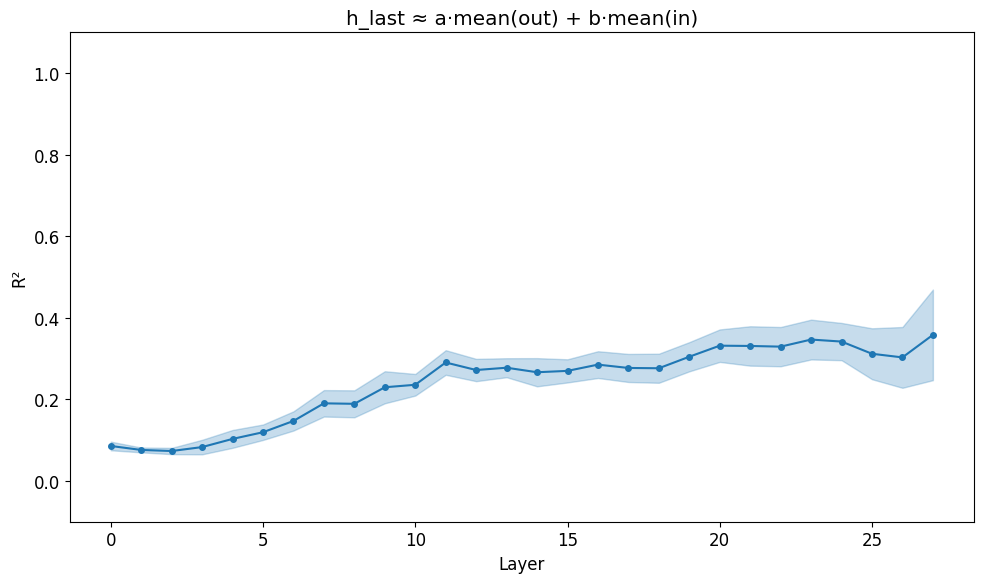

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

layers = list(range(n_layers))
all_tn = list(decomp_per_prompt.keys())

# For each task and layer, compute the mean R² across prompts.
# Then average those task-level means across tasks.
r2_matrix = np.array([
    [np.mean([r['r_squared'] for r in decomp_per_prompt[tn][l]]) for l in layers]
    for tn in all_tn
])
mean_r2 = r2_matrix.mean(axis=0)
std_r2 = r2_matrix.std(axis=0)

ax.plot(layers, mean_r2, 'o-', ms=4, color='tab:blue')
ax.fill_between(layers, mean_r2 - std_r2, mean_r2 + std_r2, alpha=0.25, color='tab:blue')

ax.set_xlabel('Layer')
ax.set_ylabel('R²')
ax.set_title('h_last ≈ a·mean(out) + b·mean(in)')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

## 9. Attention Patterns

In [16]:
import os
os.makedirs('attn_patterns', exist_ok=True)

cap_task = [tn for tn in all_task_splits if 'capital' in tn.lower() or 'country' in tn.lower()][0]
pdata = all_task_splits[cap_task]['tv_prompts'][0]
prompt = pdata['prompt']
tokens = model.to_tokens(prompt, prepend_bos=True)
str_tokens = model.to_str_tokens(prompt, prepend_bos=True)

with torch.no_grad():
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: "pattern" in name)

for l in range(n_layers):
    pat = cache['pattern', l][0].cpu().float().numpy()
    last_row = pat[:, -1, :]

    fig, ax = plt.subplots(figsize=(24, 6))
    sns.heatmap(last_row, ax=ax, cmap='viridis', vmin=0, vmax=0.3,
                xticklabels=str_tokens, yticklabels=[f'H{h}' for h in range(n_heads)])
    ax.set_title(f'Layer {l} — {cap_task} — last token attention')
    ax.tick_params(axis='x', rotation=90, labelsize=5)
    plt.tight_layout()
    plt.savefig(f'attn_patterns/last_tok_layer_{l:02d}.png', dpi=150, bbox_inches='tight')
    plt.close()

del cache
print(f'Saved {n_layers} plots to attn_patterns/')

Saved 28 plots to attn_patterns/


## 9. Attention Selectivity

For each (layer, head): how much attention from the last token goes to
input vs output positions? If some heads preferentially attend to inputs
and others to outputs, this could be the mechanism producing the diff-means structure.

In [17]:
PATTERN_FILTER = lambda name: "pattern" in name

attn_to_input = np.zeros((n_layers, n_heads))
attn_to_output = np.zeros((n_layers, n_heads))
attn_to_sep = np.zeros((n_layers, n_heads))
attn_to_self = np.zeros((n_layers, n_heads))
n_samples = 0

for task_name, splits in all_task_splits.items():
    print(f"{task_name}")
    for pdata in tqdm(splits['tv_prompts'], desc=f"  {task_name}"):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        roles = find_role_positions(model, prompt, pdata['demo_pairs'], pdata['query_input'])

        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)

        in_idx = list(set(roles['input_positions']))
        out_idx = list(set(roles['output_positions']))

        for layer in range(n_layers):
            pat = cache['pattern', layer][0].cpu().float().numpy()  # (n_heads, seq, seq)
            row = pat[:, last_pos, :]  # (n_heads, seq)
            attn_to_input[layer] += row[:, in_idx].sum(axis=1) if in_idx else 0
            attn_to_output[layer] += row[:, out_idx].sum(axis=1) if out_idx else 0
            attn_to_self[layer] += row[:, last_pos]

        n_samples += 1
        del cache
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

attn_to_input /= n_samples
attn_to_output /= n_samples
attn_to_self /= n_samples
selectivity = attn_to_output - attn_to_input

print(f"\nAveraged over {n_samples} prompts across {len(all_task_splits)} tasks.")

knowledge/country_capital


  knowledge/country_capital: 100%|██████████| 50/50 [00:02<00:00, 16.89it/s]


knowledge/football_player_position


  knowledge/football_player_position: 100%|██████████| 50/50 [00:03<00:00, 16.49it/s]


knowledge/location_continent


...

translation/fr_en


  translation/fr_en: 100%|██████████| 50/50 [00:02<00:00, 18.10it/s]


translation/it_en


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 18.03it/s]


Averaged over 1000 prompts across 20 tasks.


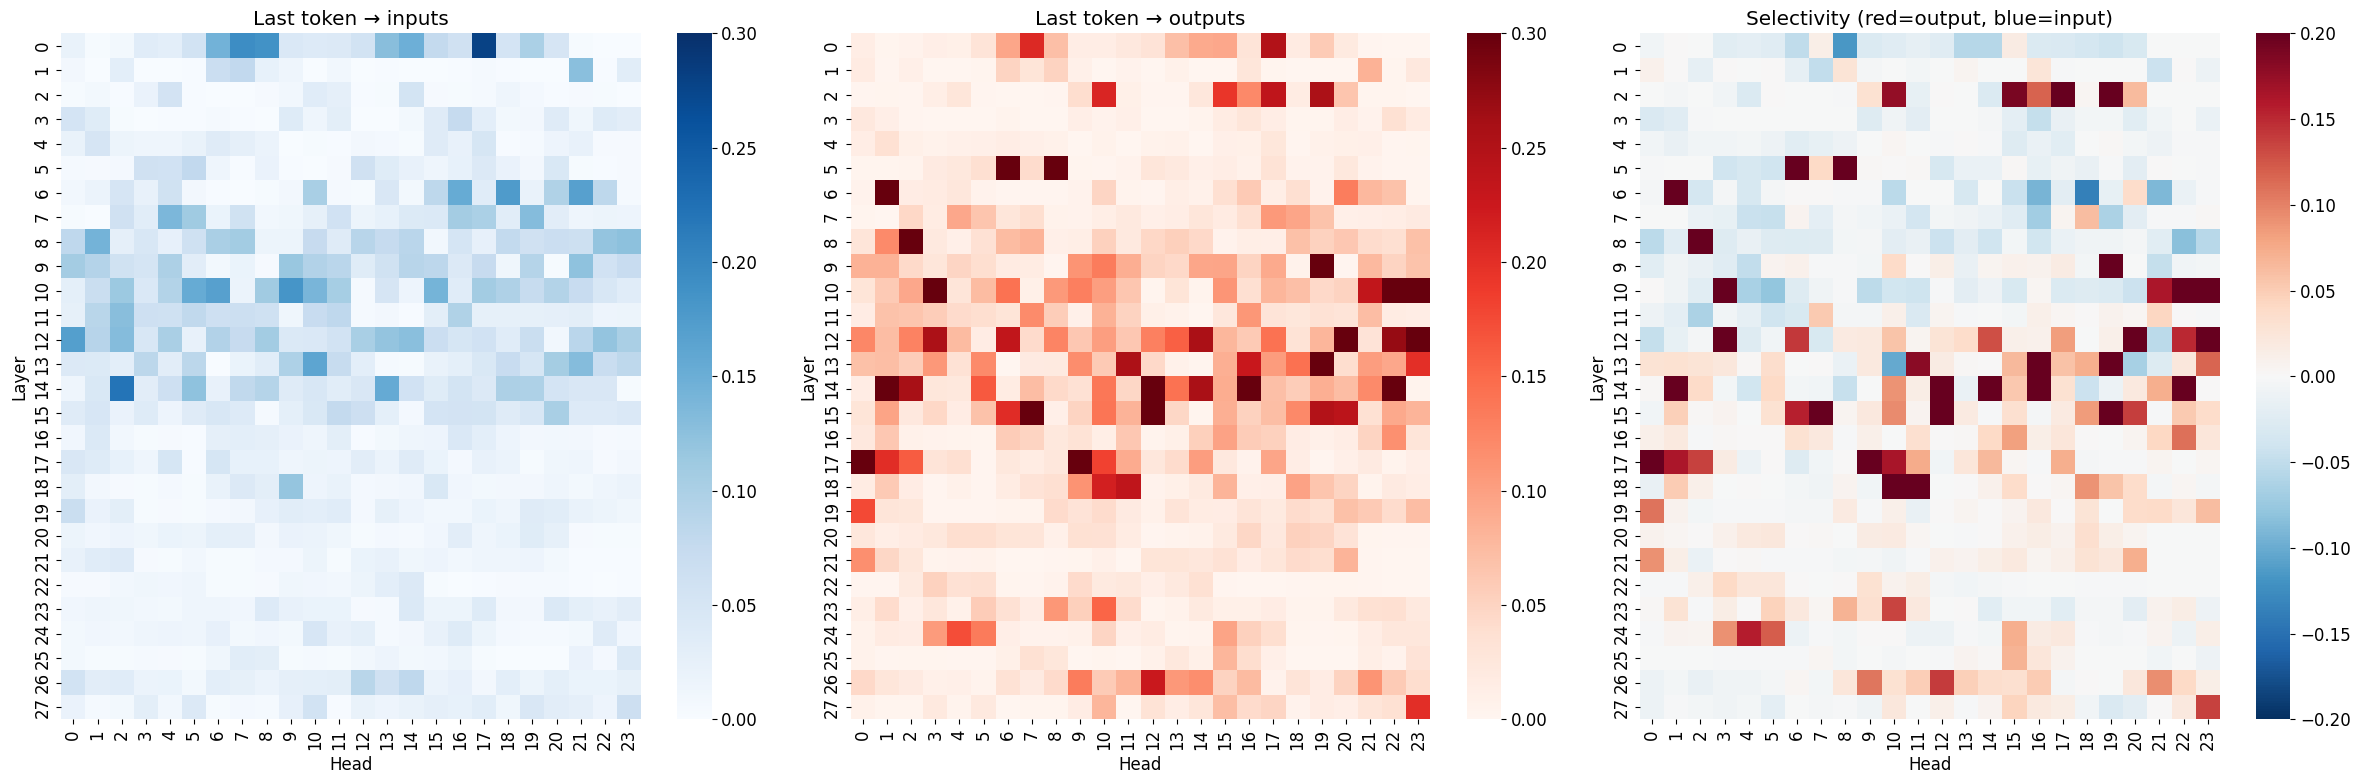

Top INPUT-preferring:
  L6H18: -0.137  (in=0.175, out=0.038)
  L0H8: -0.116  (in=0.187, out=0.071)
  L13H10: -0.103  (in=0.163, out=0.060)
  L6H16: -0.093  (in=0.154, out=0.061)
  L6H21: -0.090  (in=0.168, out=0.078)
  L8H22: -0.083  (in=0.121, out=0.038)
  L10H5: -0.079  (in=0.154, out=0.075)
  L7H16: -0.069  (in=0.108, out=0.039)
  L13H20: -0.066  (in=0.107, out=0.040)
  L10H4: -0.064  (in=0.093, out=0.029)

Top OUTPUT-preferring:
  L12H23: 0.381  (in=0.102, out=0.483)
  L17H0: 0.511  (in=0.046, out=0.557)
  L14H22: 0.516  (in=0.046, out=0.562)
  L6H1: 0.541  (in=0.019, out=0.559)
  L10H3: 0.543  (in=0.044, out=0.587)
  L14H1: 0.568  (in=0.045, out=0.612)
  L10H22: 0.570  (in=0.047, out=0.617)
  L14H12: 0.591  (in=0.047, out=0.638)
  L8H2: 0.655  (in=0.028, out=0.682)
  L12H20: 0.906  (in=0.010, out=0.916)


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.heatmap(attn_to_input, ax=axes[0], cmap='Blues', vmin=0, vmax=0.3)
axes[0].set_title('Last token → inputs')
axes[0].set_xlabel('Head'); axes[0].set_ylabel('Layer')

sns.heatmap(attn_to_output, ax=axes[1], cmap='Reds', vmin=0, vmax=0.3)
axes[1].set_title('Last token → outputs')
axes[1].set_xlabel('Head'); axes[1].set_ylabel('Layer')

sns.heatmap(selectivity, ax=axes[2], cmap='RdBu_r', center=0, vmin=-0.2, vmax=0.2)
axes[2].set_title('Selectivity (red=output, blue=input)')
axes[2].set_xlabel('Head'); axes[2].set_ylabel('Layer')

plt.tight_layout()
plt.show()

# Print the most selective heads
ranked = sorted([(l, h, selectivity[l, h]) for l in range(n_layers) for h in range(n_heads)],
                key=lambda x: x[2])
print("Top INPUT-preferring:")
for l, h, s in ranked[:10]:
    print(f"  L{l}H{h}: {s:.3f}  (in={attn_to_input[l,h]:.3f}, out={attn_to_output[l,h]:.3f})")
print("\nTop OUTPUT-preferring:")
for l, h, s in ranked[-10:]:
    print(f"  L{l}H{h}: {s:.3f}  (in={attn_to_input[l,h]:.3f}, out={attn_to_output[l,h]:.3f})")

In [19]:
cap_task = [tn for tn in all_task_splits if 'capital' in tn.lower()][0]
pdata = all_task_splits[cap_task]['tv_prompts'][0]
prompt = pdata['prompt']
str_tokens = model.to_str_tokens(prompt, prepend_bos=True)
roles = find_role_positions(model, prompt, pdata['demo_pairs'], pdata['query_input'])

print("Prompt:", prompt)
print()
for i, t in enumerate(str_tokens):
    label = ''
    if i in roles['input_positions']: label = ' ← INPUT'
    if i in roles['output_positions']: label = ' ← OUTPUT'
    print(f"  {i:3d}: {repr(t):15s}{label}")

Prompt: England → Winchester
Metropolis of Greater Paris → Paris
Saxony → Dresden
Lebanon → Beirut
Kingdom of Italy → Florence
First Czechoslovak Republic → Prague
Lazio → Rome
Scotland → Edinburgh
Province of Florence → Florence
Dutch East Indies → Jakarta
Delhi Sultanate →

    0: '<|begin_of_text|>'
    1: 'England'       ← INPUT
    2: ' →'           
    3: ' Winchester'   ← OUTPUT
    4: '\n'           
    5: 'Met'           ← INPUT
    6: 'ropolis'       ← INPUT
    7: ' of'           ← INPUT
    8: ' Greater'      ← INPUT
    9: ' Paris'        ← INPUT
   10: ' →'           
   11: ' Paris'        ← OUTPUT
   12: '\n'           
   13: 'S'             ← INPUT
   14: 'ax'            ← INPUT
   15: 'ony'           ← INPUT
   16: ' →'           
   17: ' Dresden'      ← OUTPUT
   18: '\n'           
   19: 'Le'            ← INPUT
   20: 'ban'           ← INPUT
   21: 'on'            ← INPUT
   22: ' →'           
   23: ' Beirut'       ← OUTPUT
   24: '\n'           
   25: 'King

## 10. Head Classification: Induction, Previous-Token, Separator

For each head, compute three behavioral scores to characterize what it does:

- **Previous-token**: mean $\text{attn}[i, i{-}1]$ across all positions (classic prev-token head)
- **Induction (ICL)**: from the last token (→), attention to tokens *after* earlier occurrences of → — i.e. the output tokens. This is the ICL induction pattern.
- **Separator**: from the last token, attention to earlier → tokens themselves

Uses the same forward pass over all TV prompts.

In [20]:
# Standard induction + prev-token scores using repeated random tokens (Olsson et al.)
# Plus ICL-specific induction score from actual prompts

seq_len_rrt = 50
n_trials = 10

# Standard scores (repeated random tokens)
induction_score_std = np.zeros((n_layers, n_heads))
prev_token_score_std = np.zeros((n_layers, n_heads))

for trial in tqdm(range(n_trials), desc="RRT trials"):
    rand_tokens = torch.randint(1000, 10000, (seq_len_rrt,))
    repeated = torch.cat([
        torch.tensor([model.tokenizer.bos_token_id]), rand_tokens, rand_tokens
    ]).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        _, cache = model.run_with_cache(repeated, names_filter=PATTERN_FILTER)

    for layer in range(n_layers):
        pat = cache['pattern', layer][0].cpu().float().numpy()
        for h in range(n_heads):
            induction_score_std[layer, h] += pat[h].diagonal(-seq_len_rrt + 1).mean()
            prev_token_score_std[layer, h] += pat[h].diagonal(-1).mean()

    del cache
    if DEVICE == 'cuda': torch.cuda.empty_cache()

induction_score_std /= n_trials
prev_token_score_std /= n_trials

# ICL-specific: last → attends to token after earlier →'s (output tokens)
induction_score_icl = np.zeros((n_layers, n_heads))
separator_score = np.zeros((n_layers, n_heads))
n_icl_samples = 0

for task_name, splits in all_task_splits.items():
    for pdata in tqdm(splits['tv_prompts'], desc=task_name):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        str_tokens = model.to_str_tokens(prompt, prepend_bos=True)
        seq_len = tokens.shape[1]
        last_pos = seq_len - 1
        tok_ids = tokens[0].cpu().tolist()

        sep_positions = [i for i, t in enumerate(str_tokens) if '→' in t]
        last_tok_id = tok_ids[last_pos]
        induction_targets = [i + 1 for i in range(last_pos)
                             if tok_ids[i] == last_tok_id and i + 1 < last_pos]

        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)

        for layer in range(n_layers):
            pat = cache['pattern', layer][0].cpu().float().numpy()

            if sep_positions:
                separator_score[layer] += pat[:, last_pos, sep_positions].sum(axis=1)
            if induction_targets:
                induction_score_icl[layer] += pat[:, last_pos, induction_targets].mean(axis=1)

        n_icl_samples += 1
        del cache
        if DEVICE == 'cuda': torch.cuda.empty_cache()

induction_score_icl /= n_icl_samples
separator_score /= n_icl_samples

print(f"Standard scores: {n_trials} RRT trials")
print(f"ICL scores: {n_icl_samples} prompts")

translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 20.16it/s]

Standard scores: 10 RRT trials
ICL scores: 1000 prompts


In [21]:
# fig, axes = plt.subplots(4, 4, figsize=(32, 28))

# scores = [
#     ("Previous token (RRT)", prev_token_score_std, 'Purples', 0.3),
#     ("Induction (RRT)", induction_score_std, 'Oranges', 0.3),
#     ("Induction (ICL)", induction_score_icl, 'Oranges', 0.15),
#     ("Separator", separator_score, 'Greens', 0.3),
# ]

# for row, (name, score, cmap, vmax) in enumerate(scores):
#     sns.heatmap(attn_to_input, ax=axes[row, 0], cmap='Blues', vmin=0, vmax=0.3)
#     axes[row, 0].set_title('Last token → inputs')
#     axes[row, 0].set_xlabel('Head'); axes[row, 0].set_ylabel('Layer')

#     sns.heatmap(attn_to_output, ax=axes[row, 1], cmap='Reds', vmin=0, vmax=0.3)
#     axes[row, 1].set_title('Last token → outputs')
#     axes[row, 1].set_xlabel('Head'); axes[row, 1].set_ylabel('Layer')

#     sns.heatmap(selectivity, ax=axes[row, 2], cmap='RdBu_r', center=0, vmin=-0.2, vmax=0.2)
#     axes[row, 2].set_title('Selectivity (red=output, blue=input)')
#     axes[row, 2].set_xlabel('Head'); axes[row, 2].set_ylabel('Layer')

#     sns.heatmap(score, ax=axes[row, 3], cmap=cmap, vmin=0, vmax=vmax)
#     axes[row, 3].set_title(name)
#     axes[row, 3].set_xlabel('Head'); axes[row, 3].set_ylabel('Layer')

# plt.tight_layout()
# plt.show()

# from scipy.stats import pearsonr
# for name, score in [("prev_token_std", prev_token_score_std),
#                      ("induction_std", induction_score_std),
#                      ("induction_icl", induction_score_icl),
#                      ("separator", separator_score)]:
#     r_in, _ = pearsonr(attn_to_input.flatten(), score.flatten())
#     r_out, _ = pearsonr(attn_to_output.flatten(), score.flatten())
#     r_sel, _ = pearsonr(selectivity.flatten(), score.flatten())
#     print(f"{name:20s}: corr(input)={r_in:.3f}, corr(output)={r_out:.3f}, corr(selectivity)={r_sel:.3f}")

## 12. Function Vector Head Scores (Todd et al. AIE)

**Average Indirect Effect** identifies heads whose mean activation *alone* can recover task performance.

Procedure (Todd et al., 2024):
1. Compute mean head output $\bar{a}^t_{\ell,h}$ at the last token across clean ICL prompts
2. Build corrupted prompts by shuffling output labels
3. Run corrupted prompt, but patch head $(\ell, h)$'s output with $\bar{a}^t_{\ell,h}$
4. $\text{AIE}(\ell, h) = P(\text{correct} \mid \text{patched}) - P(\text{correct} \mid \text{corrupted})$

**Efficiency**: instead of patching one head at a time ($L \times H$ forward passes per prompt),
we do a single clean forward pass per prompt to cache all head outputs, and a single corrupted
forward pass to cache activations. Then we use `model.run_with_hooks` to patch each head.
To keep runtime manageable we use `N_AIE_PROMPTS` corrupted prompts per task.

In [22]:
# Step 1: Compute mean head outputs at last token across clean ICL prompts per task

HEAD_Z_FILTER = lambda name: "hook_z" in name

mean_head_outputs = {}  # task -> tensor (n_layers, n_heads, d_head)

for task_name, splits in all_task_splits.items():
    print(f"Mean head outputs: {task_name}")
    head_accum = torch.zeros(n_layers, n_heads, model.cfg.d_head)
    n = 0
    for pdata in tqdm(splits['tv_prompts'], desc=f"  {task_name}"):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1

        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=HEAD_Z_FILTER)

        for layer in range(n_layers):
            # hook_z shape: (1, seq, n_heads, d_head)
            head_accum[layer] += cache[f'blocks.{layer}.attn.hook_z'][0, last_pos].cpu().float()

        n += 1
        del cache
        if DEVICE == 'cuda': torch.cuda.empty_cache()

    mean_head_outputs[task_name] = head_accum / n
    print(f"  Averaged over {n} prompts")

print("Done.")

Mean head outputs: knowledge/country_capital


  knowledge/country_capital: 100%|██████████| 50/50 [00:02<00:00, 21.05it/s]


  Averaged over 50 prompts
Mean head outputs: knowledge/football_player_position


  knowledge/football_player_position: 100%|██████████| 50/50 [00:02<00:00, 20.97it/s]


  Averaged over 50 prompts
Mean head outputs: knowledge/location_continent


...

  Averaged over 50 prompts
Mean head outputs: translation/fr_en


  translation/fr_en: 100%|██████████| 50/50 [00:02<00:00, 21.43it/s]


  Averaged over 50 prompts
Mean head outputs: translation/it_en


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 21.48it/s]

  Averaged over 50 prompts
Done.


In [23]:
# Step 2: Compute AIE using logprob difference (more sensitive than accuracy)

import random

N_AIE_PROMPTS = 5

aie_scores = np.zeros((n_layers, n_heads))
n_aie_total = 0

for task_name, splits in all_task_splits.items():
    print(f"AIE: {task_name}")
    mean_heads = mean_head_outputs[task_name].to(DEVICE).to(model.cfg.dtype)
    eval_data = splits['eval_data'][:N_AIE_PROMPTS]

    for eq in tqdm(eval_data, desc=f"  {task_name}"):
        target = eq['query_output']
        demo_pairs = eq['demo_pairs']
        query_input = eq['query_input']

        # Get target token id
        target_toks = model.tokenizer.encode(" " + target)
        if not target_toks:
            continue
        target_id = target_toks[0]

        # Shuffle outputs
        outputs = [out for _, out in demo_pairs]
        for _ in range(20):
            random.shuffle(outputs)
            if any(o != orig for (_, orig), o in zip(demo_pairs, outputs)):
                break
        corrupted_pairs = [(inp, o) for (inp, _), o in zip(demo_pairs, outputs)]
        corrupted_prompt = build_icl_prompt(corrupted_pairs, query_input)

        tokens_corr = model.to_tokens(corrupted_prompt, prepend_bos=True)
        last_pos = tokens_corr.shape[1] - 1

        # Corrupted baseline logprob
        with torch.no_grad():
            logits_corr = model(tokens_corr)
        corr_logprob = torch.log_softmax(logits_corr[0, -1], dim=-1)[target_id].item()

        # Patch each head — reuse tokens_corr
        for layer in range(n_layers):
            for h in range(n_heads):
                mean_h = mean_heads[layer, h]

                def patch_hook(value, hook, _h=h, _mean=mean_h, _lp=last_pos):
                    value[0, _lp, _h, :] = _mean
                    return value

                with torch.no_grad():
                    logits_p = model.run_with_hooks(
                        tokens_corr,
                        fwd_hooks=[(f'blocks.{layer}.attn.hook_z', patch_hook)]
                    )
                patched_logprob = torch.log_softmax(logits_p[0, -1], dim=-1)[target_id].item()
                aie_scores[layer, h] += (patched_logprob - corr_logprob)

        n_aie_total += 1
        if DEVICE == 'cuda': torch.cuda.empty_cache()

aie_scores /= max(n_aie_total, 1)
print(f"\nAIE computed over {n_aie_total} corrupted prompts.")

AIE: knowledge/country_capital


  knowledge/country_capital:  20%|██        | 1/5 [00:43<02:53, 43.25s/it]


KeyboardInterrupt: 

In [24]:
# Save all expensive computed results

results = {
    # §5 — hidden state extraction (cell 11)
    'last_token_vecs': {k: {l: v for l, v in d.items()} for k, d in last_token_vecs.items()},
    'mean_input_vecs': {k: {l: v for l, v in d.items()} for k, d in mean_input_vecs.items()},
    'mean_output_vecs': {k: {l: v for l, v in d.items()} for k, d in mean_output_vecs.items()},
    # §5 — task vectors (cell 12)
    'task_vectors': {k: {l: v for l, v in d.items()} for k, d in task_vectors.items()},
    # §6 — patching accuracy (cell 15)
    'patching_acc': {k: dict(v) for k, v in patching_acc.items()},
    'icl_acc': dict(icl_acc),
    'zs_acc': dict(zs_acc),
    # # §8 — diffmeans decomposition (cell 19)
    # 'decomp_per_prompt': dict(decomp_per_prompt) if decomp_per_prompt is not None else None,
    # §9 — attention selectivity (cell 24)
    'attn_to_input': attn_to_input,
    'attn_to_output': attn_to_output,
    'selectivity': selectivity,
    # §10 — head classification (cell 28)
    'induction_score_std': induction_score_std,
    'prev_token_score_std': prev_token_score_std,
    'induction_score_icl': induction_score_icl,
    'separator_score': separator_score,
    # §12 — FV / AIE (cells 31-32)
    'mean_head_outputs': {k: v.cpu() for k, v in mean_head_outputs.items()},
    # 'aie_scores': aie_scores,
    # 'n_aie_total': n_aie_total,
}

save_path = 'diffmeans_results.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)
print(f'Saved to {save_path} ({os.path.getsize(save_path) / 1e6:.1f} MB)')

Saved to diffmeans_results.pkl (1049.0 MB)


In [25]:
# Load previously saved results

save_path = 'diffmeans_results.pkl'
with open(save_path, 'rb') as f:
    results = pickle.load(f)

# Unpack everything
last_token_vecs = results['last_token_vecs']
mean_input_vecs = results['mean_input_vecs']
mean_output_vecs = results['mean_output_vecs']
task_vectors = results['task_vectors']
patching_acc = results['patching_acc']
icl_acc = results['icl_acc']
zs_acc = results['zs_acc']
# decomp_per_prompt = results.get('decomp_per_prompt')
attn_to_input = results['attn_to_input']
attn_to_output = results['attn_to_output']
selectivity = results['selectivity']
induction_score_std = results['induction_score_std']
prev_token_score_std = results['prev_token_score_std']
induction_score_icl = results['induction_score_icl']
separator_score = results['separator_score']
mean_head_outputs = results['mean_head_outputs']
# aie_scores = results['aie_scores']
# n_aie_total = results['n_aie_total']

print(f'Loaded from {save_path}')
# print(f'AIE: {n_aie_total} corrupted prompts, shape {aie_scores.shape}')

Loaded from diffmeans_results.pkl


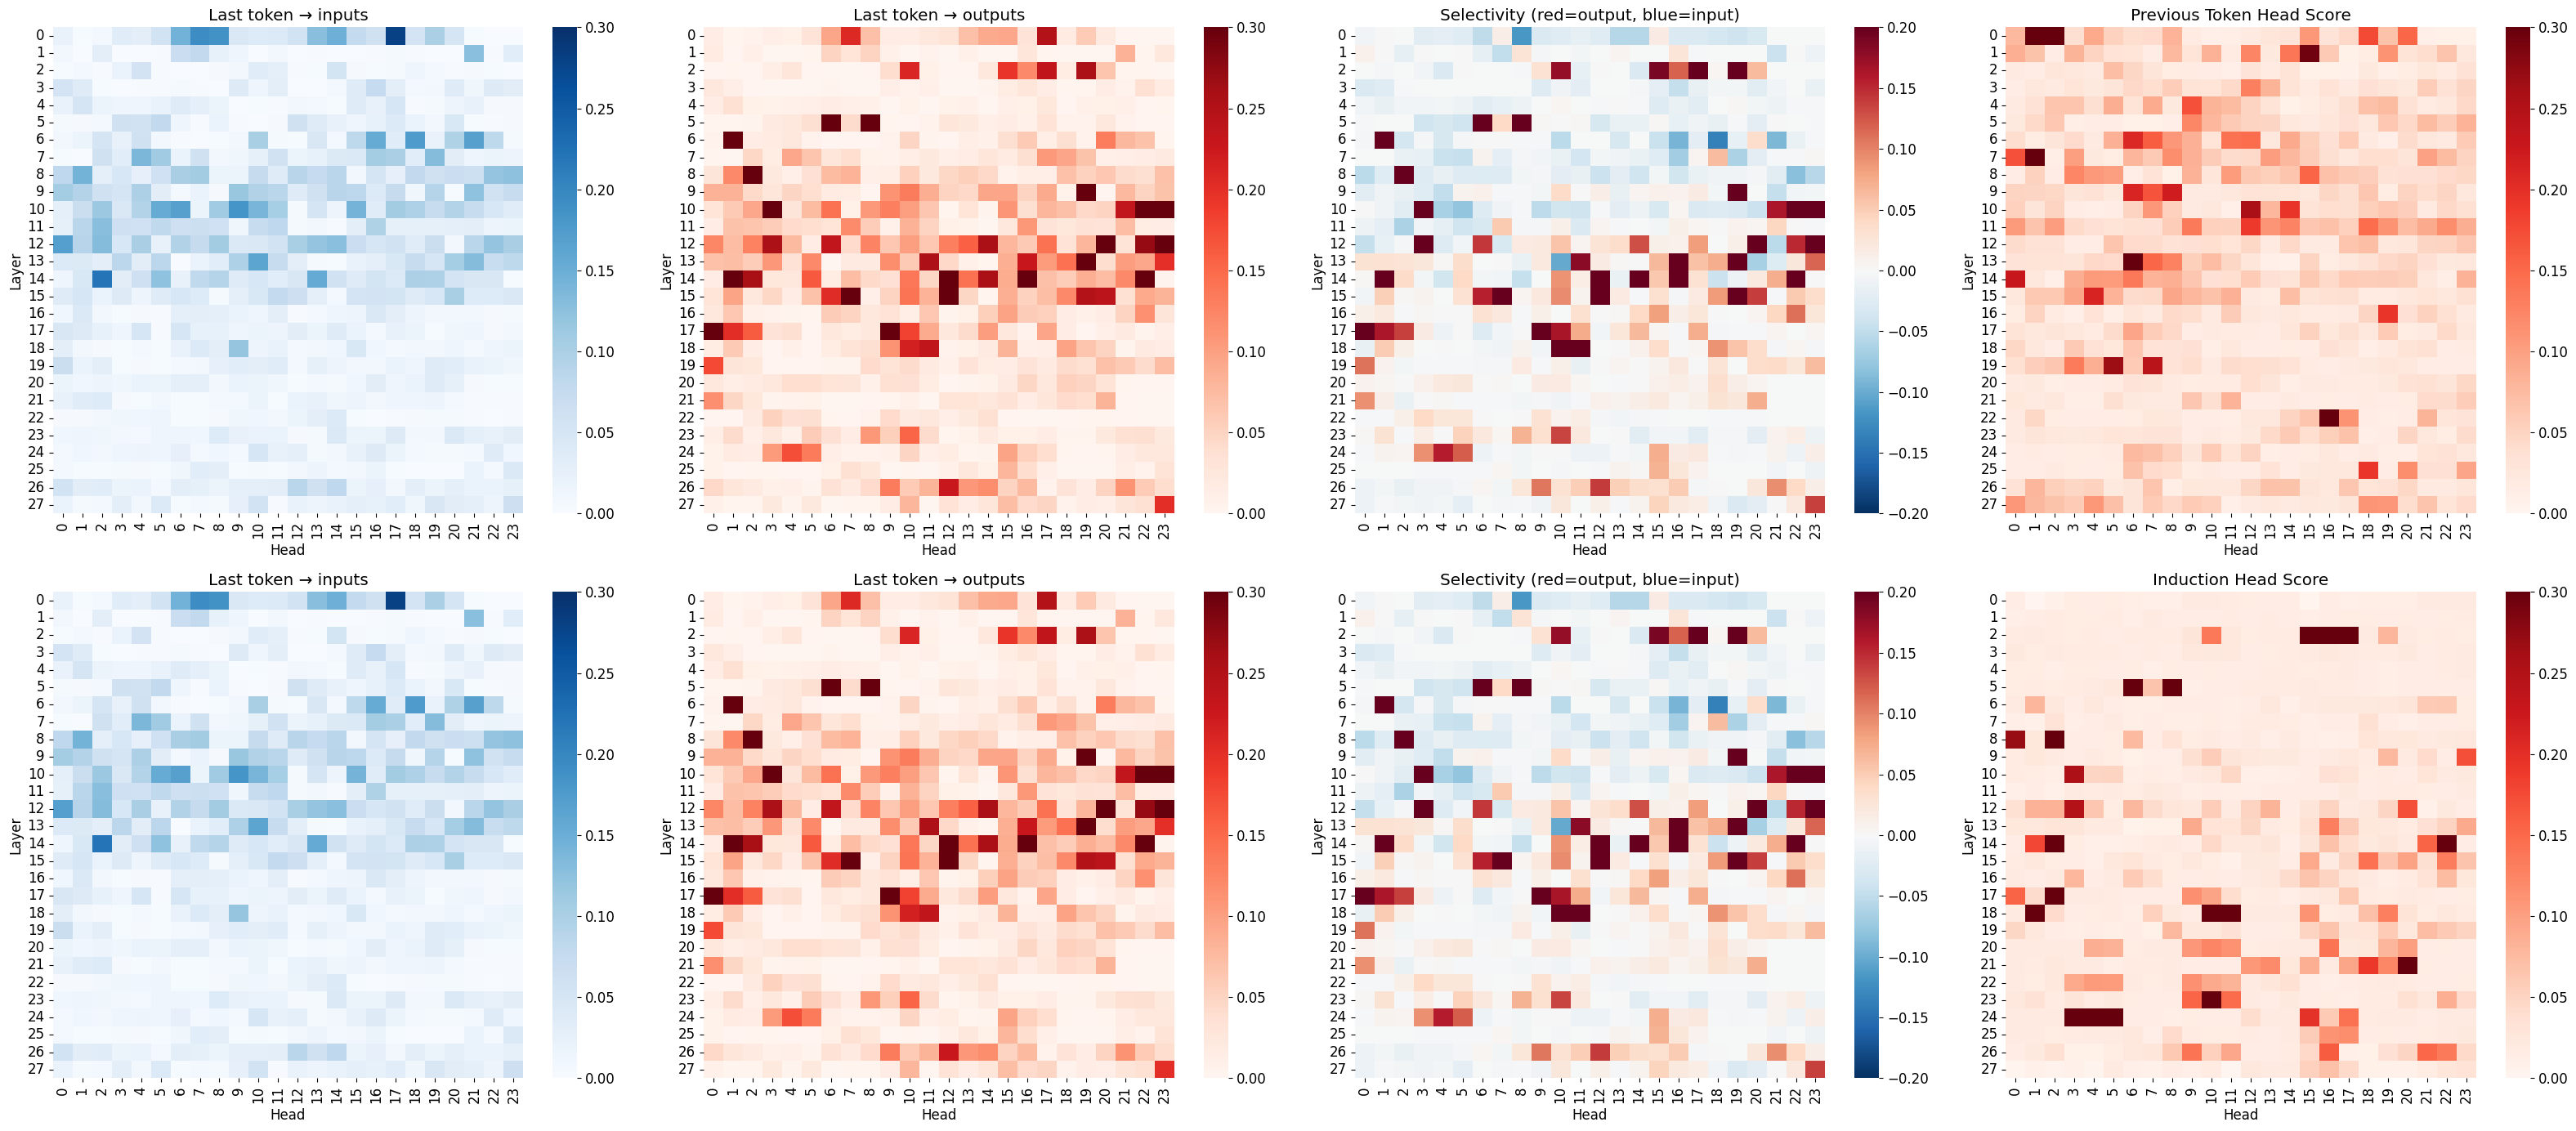

prev_token          : corr(input)=-0.103, corr(output)=-0.146, corr(selectivity)=-0.110
induction           : corr(input)=0.027, corr(output)=0.468, corr(selectivity)=0.483


In [26]:
fig, axes = plt.subplots(2, 4, figsize=(32, 21 * 2/3))

scores = [
    ("Previous Token Head Score", prev_token_score_std, 'Purples', 0.3),
    ("Induction Head Score", induction_score_std, 'Oranges', 0.3),
    # ("Induction (ICL)", induction_score_icl, 'Oranges', 0.15),
    # ("Separator", separator_score, 'Greens', 0.3),
    # ("FV Head Score (AIE)", aie_scores, 'YlOrRd', max(0.05, aie_scores.max() * 0.8)),
]

for row, (name, score, cmap, vmax) in enumerate(scores):
    sns.heatmap(attn_to_input, ax=axes[row, 0], cmap='Blues', vmin=0, vmax=0.3)
    axes[row, 0].set_title('Last token → inputs')
    axes[row, 0].set_xlabel('Head'); axes[row, 0].set_ylabel('Layer')

    sns.heatmap(attn_to_output, ax=axes[row, 1], cmap='Reds', vmin=0, vmax=0.3)
    axes[row, 1].set_title('Last token → outputs')
    axes[row, 1].set_xlabel('Head'); axes[row, 1].set_ylabel('Layer')

    sns.heatmap(selectivity, ax=axes[row, 2], cmap='RdBu_r', center=0, vmin=-0.2, vmax=0.2)
    axes[row, 2].set_title('Selectivity (red=output, blue=input)')
    axes[row, 2].set_xlabel('Head'); axes[row, 2].set_ylabel('Layer')

    sns.heatmap(score, ax=axes[row, 3], cmap='Reds', vmin=0, vmax=vmax)
    axes[row, 3].set_title(name)
    axes[row, 3].set_xlabel('Head'); axes[row, 3].set_ylabel('Layer')

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr
for name, score in [("prev_token", prev_token_score_std),
                     ("induction", induction_score_std),
                    #  ("induction_icl", induction_score_icl),
                    #  ("separator", separator_score),
                    #  ("aie", aie_scores)
                    ]:
    r_in, _ = pearsonr(attn_to_input.flatten(), score.flatten())
    r_out, _ = pearsonr(attn_to_output.flatten(), score.flatten())
    r_sel, _ = pearsonr(selectivity.flatten(), score.flatten())
    print(f"{name:20s}: corr(input)={r_in:.3f}, corr(output)={r_out:.3f}, corr(selectivity)={r_sel:.3f}")

## Patching

In [27]:
# Select head groups by top/bottom 10%
induction_threshold = np.percentile(induction_score_std, 90)
top_induction = [(l, h) for l in range(n_layers) for h in range(n_heads)
                 if induction_score_std[l, h] >= induction_threshold]

# aie_threshold = np.percentile(aie_scores, 90)
# top_aie = [(l, h) for l in range(n_layers) for h in range(n_heads)
#            if aie_scores[l, h] >= aie_threshold]

# bottom_aie_threshold = np.percentile(aie_scores, 10)
# bottom_aie = [(l, h) for l in range(n_layers) for h in range(n_heads)
#               if aie_scores[l, h] <= bottom_aie_threshold]

test_heads = {
    'top 10% induction': top_induction,
    # 'top 10% AIE': top_aie,
    # 'bottom 10% AIE': bottom_aie,
}

for gn, heads in test_heads.items():
    print(f"{gn} ({len(heads)} heads):")
    for l, h in heads:
        print(f"  L{l}H{h}: induction={induction_score_std[l,h]:.3f}, ")
            #   f"AIE={aie_scores[l,h]:.4f}, selectivity={selectivity[l,h]:.3f}")

top 10% induction (68 heads):
  L2H10: induction=0.137, 
  L2H15: induction=0.321, 
  L2H16: induction=0.685, 
  L2H17: induction=0.453, 
  L5H6: induction=0.652, 
  L5H8: induction=0.643, 
  L8H0: induction=0.270, 
  L8H2: induction=0.696, 
  L9H23: induction=0.171, 
  L10H3: induction=0.254, 
  L12H1: induction=0.084, 
  L12H2: induction=0.084, 
  L12H3: induction=0.249, 
  L12H20: induction=0.172, 
  L13H9: induction=0.091, 
  L13H16: induction=0.129, 
  L13H23: induction=0.090, 
  L14H1: induction=0.178, 
  L14H2: induction=0.846, 
  L14H21: induction=0.155, 
  L14H22: induction=0.934, 
  L15H15: induction=0.092, 
  L15H18: induction=0.143, 
  L15H20: induction=0.098, 
  L15H22: induction=0.131, 
  L17H0: induction=0.155, 
  L17H2: induction=0.374, 
  L17H9: induction=0.115, 
  L17H10: induction=0.096, 
  L18H1: induction=0.475, 
  L18H10: induction=0.381, 
  L18H11: induction=0.561, 
  L18H15: induction=0.111, 
  L18H19: induction=0.129, 
  L20H4: induction=0.087, 
  L20H9: induct

In [28]:
# Compute W_O @ mean_z for all heads, all tasks
head_contrib = {}
for task_name in all_task_splits:
    if task_name not in mean_head_outputs:
        continue
    mean_z = mean_head_outputs[task_name]
    head_contrib[task_name] = {}
    for layer in range(n_layers):
        W_O = model.blocks[layer].attn.W_O.detach().cpu().float()
        for h in range(n_heads):
            z_h = mean_z[layer, h].numpy()
            head_contrib[task_name][(layer, h)] = W_O[h].numpy().T @ z_h

print(f"Head contributions computed for {len(head_contrib)} tasks")

Head contributions computed for 20 tasks


In [29]:
# Replace head outputs at their native layers with mean ICL outputs

head_patch_acc_replace = {}

for group_name, heads in test_heads.items():
    print(f"\nPatching group: {group_name} — {len(heads)} heads")
    head_patch_acc_replace[group_name] = []

    for task_name, splits in all_task_splits.items():
        if task_name not in mean_head_outputs:
            continue

        mean_z = mean_head_outputs[task_name]

        heads_by_layer = defaultdict(list)
        for (l, h) in heads:
            heads_by_layer[l].append(h)

        task_accs = []
        for eq in tqdm(splits['eval_data'], desc=f"  {task_name}"):
            target = eq['query_output']
            tokens = model.to_tokens(eq['zs_prompt'], prepend_bos=True)

            fwd_hooks = []
            for l, h_list in heads_by_layer.items():
                mean_z_layer = mean_z[l].to(DEVICE).to(model.cfg.dtype)

                def replace_hook(z, hook, _h_list=h_list, _mean_z=mean_z_layer):
                    last_pos = z.shape[1] - 1
                    for h in _h_list:
                        z[0, last_pos, h, :] = _mean_z[h]
                    return z

                fwd_hooks.append((f'blocks.{l}.attn.hook_z', replace_hook))

            with torch.no_grad():
                logits = model.run_with_hooks(tokens, fwd_hooks=fwd_hooks)
            task_accs.append(float(check_correct(model, logits[0, -1], target)))

        head_patch_acc_replace[group_name].append(np.mean(task_accs))
        if DEVICE == 'cuda': torch.cuda.empty_cache()

    print(f"  Mean acc: {np.mean(head_patch_acc_replace[group_name]):.3f}")


Patching group: top 10% induction — 68 heads


  translation/it_en: 100%|██████████| 20/20 [00:00<00:00, 24.01it/s]

  Mean acc: 0.360


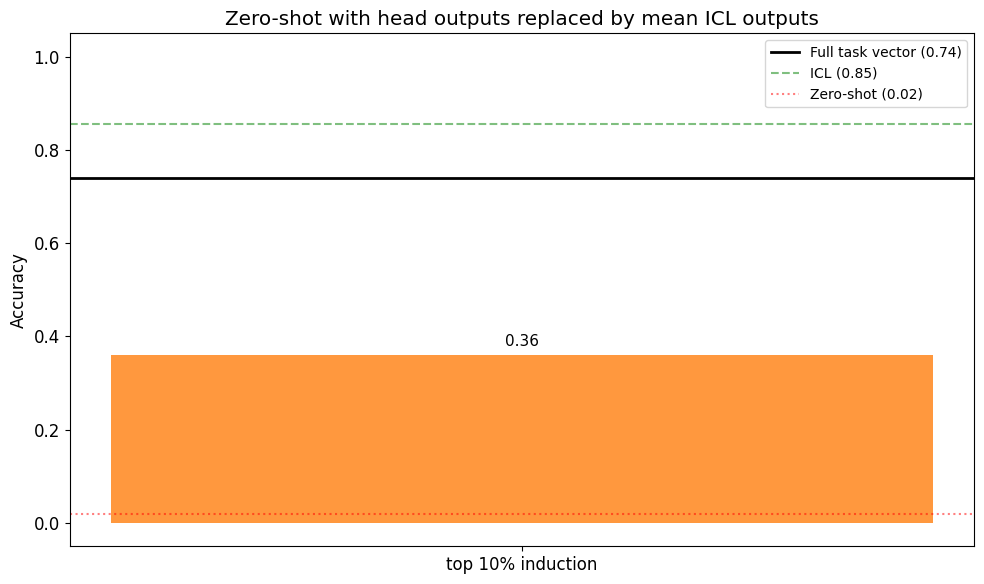

top 10% induction: mean=0.360, min=0.000, max=0.950


In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

all_tn = list(all_task_splits.keys())
# tv_baseline = np.mean([max(np.mean(patching_acc[tn][l]) for l in range(n_layers)) for tn in all_tn])
tv_baseline = max(np.mean([np.mean(patching_acc[tn][l]) for tn in all_tn]) for l in range(n_layers))

group_names = list(head_patch_acc_replace.keys())
group_accs = [np.mean(head_patch_acc_replace[gn]) for gn in group_names]
colors = {'top 10% induction': 'tab:orange', 'top 10% AIE': 'tab:red', 'bottom 10% AIE': 'tab:gray'}

ax.bar(group_names, group_accs, color=[colors.get(gn, 'tab:blue') for gn in group_names], alpha=0.8)
ax.axhline(tv_baseline, ls='-', color='black', lw=2, label=f'Full task vector ({tv_baseline:.2f})')

avg_icl = np.mean([np.mean(icl_acc[tn]) for tn in all_tn])
avg_zs = np.mean([np.mean(zs_acc[tn]) for tn in all_tn])
ax.axhline(avg_icl, ls='--', color='green', alpha=0.5, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.5, label=f'Zero-shot ({avg_zs:.2f})')

ax.set_ylabel('Accuracy')
ax.set_title('Zero-shot with head outputs replaced by mean ICL outputs')
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.05)

for i, (gn, acc) in enumerate(zip(group_names, group_accs)):
    ax.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

for gn in group_names:
    per_task = head_patch_acc_replace[gn]
    print(f"{gn}: mean={np.mean(per_task):.3f}, min={np.min(per_task):.3f}, max={np.max(per_task):.3f}")


In [31]:
# Yang et al. replication: sum IH outputs, add to zero-shot at best patching layer

# Best patching layer per task
best_patch_layer = {}
for task_name in all_task_splits:
    accs = [np.mean(patching_acc[task_name][l]) for l in range(n_layers)]
    best_patch_layer[task_name] = int(np.argmax(accs))

# Also compute a single global best layer (like Yang et al. used layer 30 for all tasks)
global_best = int(np.argmax([
    np.mean([np.mean(patching_acc[tn][l]) for tn in all_task_splits]) 
    for l in range(n_layers)
]))
print(f"Global best patching layer: {global_best}")

# Build IH task vector per task: sum of W_O @ mean_z across top induction heads
ih_tv = {}
for task_name in all_task_splits:
    if task_name not in mean_head_outputs:
        continue
    mean_z = mean_head_outputs[task_name]
    vec = np.zeros(d_model)
    for (l, h) in top_induction:
        W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
        z_h = mean_z[l, h].numpy()
        vec += W_O.T @ z_h
    ih_tv[task_name] = vec

# Evaluate: add IH task vector to zero-shot at global best layer
ih_acc_global = defaultdict(list)
ih_acc_pertask = defaultdict(list)

for task_name, splits in all_task_splits.items():
    if task_name not in ih_tv:
        continue

    tv_global = torch.tensor(ih_tv[task_name], device=DEVICE, dtype=model.cfg.dtype)
    L_global = global_best
    L_pertask = best_patch_layer[task_name]
    tv_pertask = tv_global.clone()

    for eq in tqdm(splits['eval_data'], desc=f"  {task_name}"):
        target = eq['query_output']
        tokens = model.to_tokens(eq['zs_prompt'], prepend_bos=True)

        # Global layer (Yang et al. style)
        def add_hook_global(value, hook, _tv=tv_global):
            value[0, -1, :] += _tv
            return value
        with torch.no_grad():
            logits = model.run_with_hooks(tokens,
                fwd_hooks=[(f'blocks.{L_global}.hook_resid_post', add_hook_global)])
        ih_acc_global[task_name].append(float(check_correct(model, logits[0, -1], target)))

        # Per-task best layer
        def add_hook_pertask(value, hook, _tv=tv_pertask):
            value[0, -1, :] += _tv
            return value
        with torch.no_grad():
            logits = model.run_with_hooks(tokens,
                fwd_hooks=[(f'blocks.{L_pertask}.hook_resid_post', add_hook_pertask)])
        ih_acc_pertask[task_name].append(float(check_correct(model, logits[0, -1], target)))

    print(f"  {task_name}: global_L{L_global}={np.mean(ih_acc_global[task_name]):.3f}, "
          f"best_L{L_pertask}={np.mean(ih_acc_pertask[task_name]):.3f}")

# Summary
tv_baseline = max(np.mean([np.mean(patching_acc[tn][l]) for tn in all_task_splits]) 
                   for l in range(n_layers))
avg_icl = np.mean([np.mean(icl_acc[tn]) for tn in all_task_splits])
avg_zs = np.mean([np.mean(zs_acc[tn]) for tn in all_task_splits])

print(f"\n{'Metric':40s} {'Accuracy':>10s}")
print(f"{'Zero-shot':40s} {avg_zs:10.3f}")
print(f"{'IH task vector (global layer {})'.format(global_best):40s} "
      f"{np.mean([np.mean(v) for v in ih_acc_global.values()]):10.3f}")
print(f"{'IH task vector (per-task best layer)':40s} "
      f"{np.mean([np.mean(v) for v in ih_acc_pertask.values()]):10.3f}")
print(f"{'Full task vector (peak of mean curve)':40s} {tv_baseline:10.3f}")
print(f"{'ICL':40s} {avg_icl:10.3f}")

Global best patching layer: 14


  knowledge/country_capital: 100%|██████████| 20/20 [00:01<00:00, 12.13it/s]


  knowledge/country_capital: global_L14=0.250, best_L13=0.350


  knowledge/football_player_position: 100%|██████████| 20/20 [00:01<00:00, 12.50it/s]


  knowledge/football_player_position: global_L14=0.050, best_L17=0.100


...

  translation/es_en: global_L14=0.050, best_L12=0.350


  translation/fr_en: 100%|██████████| 20/20 [00:01<00:00, 12.56it/s]


  translation/fr_en: global_L14=0.050, best_L12=0.250


  translation/it_en: 100%|██████████| 20/20 [00:01<00:00, 12.52it/s]

  translation/it_en: global_L14=0.000, best_L12=0.250

Metric                                     Accuracy
Zero-shot                                     0.020
IH task vector (global layer 14)              0.270
IH task vector (per-task best layer)          0.395
Full task vector (peak of mean curve)         0.740
ICL                                           0.855


## Ablating induction heads

In [32]:
# Ablate induction heads during ICL, extract degraded task vector, patch into zero-shot

# Unablated task vectors already computed (task_vectors from §5)
# Now compute ablated versions

ablated_task_vectors = {}

for task_name, splits in all_task_splits.items():
    print(f"Extracting ablated TV: {task_name}")
    vecs = []
    for pdata in tqdm(splits['tv_prompts'], desc=f"  {task_name}"):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1

        # Build hooks: zero out induction heads' z at last position
        fwd_hooks = []
        heads_by_layer = defaultdict(list)
        for (l, h) in top_induction:
            heads_by_layer[l].append(h)

        for l, h_list in heads_by_layer.items():
            def zero_hook(z, hook, _h_list=h_list):
                last_pos = z.shape[1] - 1
                for h in _h_list:
                    z[0, last_pos, h, :] = 0
                return z
            fwd_hooks.append((f'blocks.{l}.attn.hook_z', zero_hook))

        captured = {}
        for layer in range(n_layers):
            def capture_hook(value, hook, _layer=layer):
                last_pos = value.shape[1] - 1
                captured[_layer] = value[0, last_pos].detach().cpu().float().numpy()
                return value
            fwd_hooks.append((f'blocks.{layer}.hook_resid_post', capture_hook))

        with torch.no_grad():
            model.run_with_hooks(tokens, fwd_hooks=fwd_hooks)

        vecs.append(captured)
        if DEVICE == 'cuda': torch.cuda.empty_cache()

    # Average across prompts per layer
    ablated_task_vectors[task_name] = {}
    for layer in range(n_layers):
        ablated_task_vectors[task_name][layer] = np.mean([v[layer] for v in vecs], axis=0)

print("Done.")

Extracting ablated TV: knowledge/country_capital


  knowledge/country_capital: 100%|██████████| 50/50 [00:02<00:00, 19.87it/s]


Extracting ablated TV: knowledge/football_player_position


  knowledge/football_player_position: 100%|██████████| 50/50 [00:02<00:00, 20.15it/s]


Extracting ablated TV: knowledge/location_continent


...

Extracting ablated TV: translation/fr_en


  translation/fr_en: 100%|██████████| 50/50 [00:02<00:00, 20.41it/s]


Extracting ablated TV: translation/it_en


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 20.51it/s]

Done.


In [33]:
# Patch ablated task vectors into zero-shot and compare to unablated

ablated_patching_acc = defaultdict(lambda: defaultdict(list))

for task_name, splits in all_task_splits.items():
    print(f"Evaluating ablated TV: {task_name}")
    for edata in tqdm(splits['eval_data'], desc=f"  {task_name}"):
        target = edata['query_output']
        for layer in range(n_layers):
            theta_abl = ablated_task_vectors[task_name][layer]
            logits = eval_patched(model, edata['zs_prompt'], theta_abl, layer)
            ablated_patching_acc[task_name][layer].append(
                check_correct(model, logits, target)
            )
    if DEVICE == 'cuda': torch.cuda.empty_cache()

print("Done.")

Evaluating ablated TV: knowledge/country_capital


  knowledge/country_capital: 100%|██████████| 20/20 [00:22<00:00,  1.11s/it]


Evaluating ablated TV: knowledge/football_player_position


  knowledge/football_player_position: 100%|██████████| 20/20 [00:22<00:00,  1.11s/it]


Evaluating ablated TV: knowledge/location_continent


...

Evaluating ablated TV: translation/fr_en


  translation/fr_en: 100%|██████████| 20/20 [00:22<00:00,  1.11s/it]


Evaluating ablated TV: translation/it_en


  translation/it_en: 100%|██████████| 20/20 [00:21<00:00,  1.10s/it]

Done.


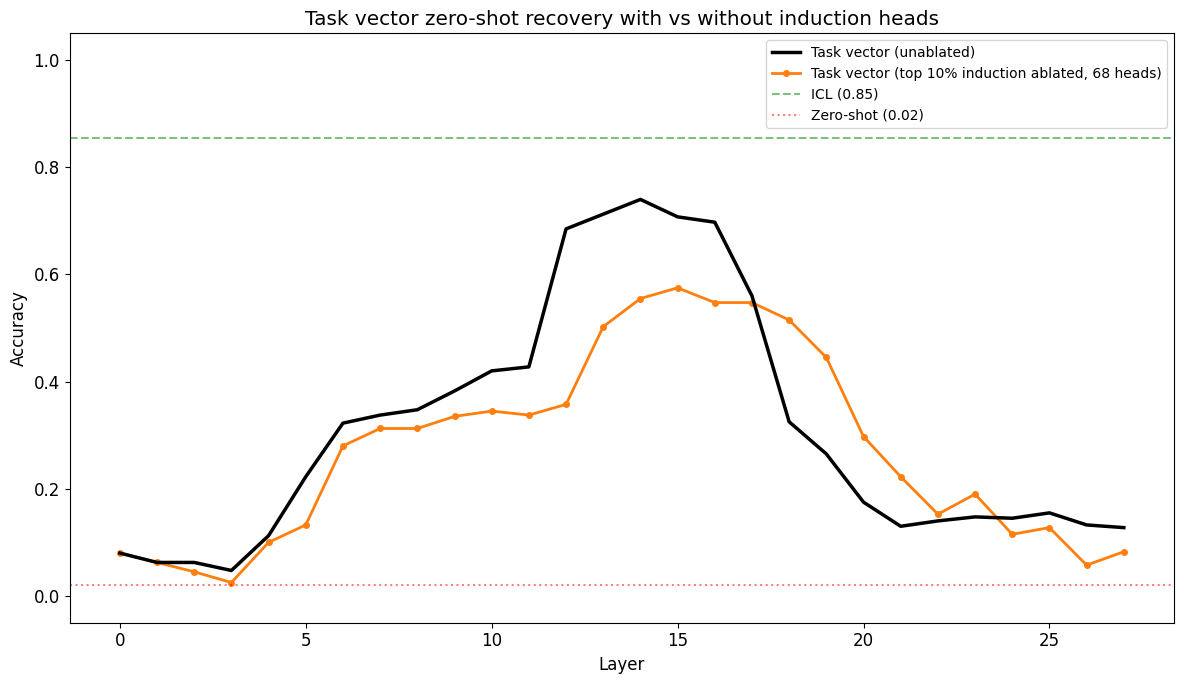

Peak unablated: 0.740 (20 tasks)
Peak ablated (no induction): 0.575 (20 tasks)
Drop: 0.165


In [34]:
# Plot: unablated vs ablated task vector accuracy curves

fig, ax = plt.subplots(figsize=(12, 7))
layers = list(range(n_layers))

# Unablated baseline — all tasks
all_tn = list(all_task_splits.keys())
tv_mean = np.array([[np.mean(patching_acc[tn][l]) for l in layers] for tn in all_tn]).mean(axis=0)
ax.plot(layers, tv_mean, 'k-', lw=2.5, label='Task vector (unablated)', zorder=10)

# Ablated — should also cover all tasks
all_tn_abl = list(ablated_patching_acc.keys())
tv_mean_abl = np.array([[np.mean(ablated_patching_acc[tn][l]) for l in layers] for tn in all_tn_abl]).mean(axis=0)
ax.plot(layers, tv_mean_abl, 'o-', color='tab:orange', lw=2, ms=4,
        label=f'Task vector (top 10% induction ablated, {len(top_induction)} heads)')

avg_icl = np.mean([np.mean(icl_acc[tn]) for tn in all_tn])
avg_zs = np.mean([np.mean(zs_acc[tn]) for tn in all_tn])
ax.axhline(avg_icl, ls='--', color='green', alpha=0.5, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.5, label=f'Zero-shot ({avg_zs:.2f})')

ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('Task vector zero-shot recovery with vs without induction heads')
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

peak_normal = max(tv_mean)
peak_ablated = max(tv_mean_abl)
print(f"Peak unablated: {peak_normal:.3f} ({len(all_tn)} tasks)")
print(f"Peak ablated (no induction): {peak_ablated:.3f} ({len(all_tn_abl)} tasks)")
print(f"Drop: {peak_normal - peak_ablated:.3f}")


## Sensitive to layer

In [35]:
# Stratify heads by layer range for BOTH selection criteria

# --- Standard induction (Olsson et al. RRT) ---
early_ind = [(l, h) for l, h in top_induction if l < 10]
middle_ind = [(l, h) for l, h in top_induction if 10 <= l < 19]
late_ind = [(l, h) for l, h in top_induction if l >= 19]

print("Top 10% by std induction score (RRT):")
print(f"  Early (L0-9):   {len(early_ind)} heads")
print(f"  Middle (L10-18): {len(middle_ind)} heads")
print(f"  Late (L19-27):  {len(late_ind)} heads")

for name, group in [('Early', early_ind), ('Middle', middle_ind), ('Late', late_ind)]:
    lc = defaultdict(int)
    for l, h in group:
        lc[l] += 1
    print(f"  {name}: {dict(sorted(lc.items()))}")

# --- Output attention (Yang et al. Appendix H) ---
output_attn_threshold = np.percentile(attn_to_output, 90)
top_output_attn = [(l, h) for l in range(n_layers) for h in range(n_heads)
                   if attn_to_output[l, h] >= output_attn_threshold]

early_oa = [(l, h) for l, h in top_output_attn if l < 10]
middle_oa = [(l, h) for l, h in top_output_attn if 10 <= l < 19]
late_oa = [(l, h) for l, h in top_output_attn if l >= 19]

print(f"\nTop 10% by output attention (Yang et al.):")
print(f"  Early (L0-9):   {len(early_oa)} heads")
print(f"  Middle (L10-18): {len(middle_oa)} heads")
print(f"  Late (L19-27):  {len(late_oa)} heads")

for name, group in [('Early', early_oa), ('Middle', middle_oa), ('Late', late_oa)]:
    lc = defaultdict(int)
    for l, h in group:
        lc[l] += 1
    print(f"  {name}: {dict(sorted(lc.items()))}")

print(f"\nOverlap (all): {len(set(top_output_attn) & set(top_induction))} / {len(top_induction)} heads")


Top 10% by std induction score (RRT):
  Early (L0-9):   9 heads
  Middle (L10-18): 25 heads
  Late (L19-27):  34 heads
  Early: {2: 4, 5: 2, 8: 2, 9: 1}
  Middle: {10: 1, 12: 4, 13: 3, 14: 4, 15: 4, 17: 4, 18: 5}
  Late: {20: 6, 21: 7, 22: 5, 23: 4, 24: 5, 25: 2, 26: 5}

Top 10% by output attention (Yang et al.):
  Early (L0-9):   14 heads
  Middle (L10-18): 47 heads
  Late (L19-27):  7 heads
  Early: {0: 2, 2: 5, 5: 2, 6: 2, 8: 1, 9: 2}
  Middle: {10: 6, 12: 12, 13: 6, 14: 9, 15: 7, 17: 5, 18: 2}
  Late: {19: 1, 23: 1, 24: 2, 26: 2, 27: 1}

Overlap (all): 28 / 68 heads


In [36]:
# Necessity: ablate heads by layer range, extract TV, patch into zero-shot
# Run for BOTH std induction and output attention head selections

ablation_groups = {
    # Standard induction (RRT)
    'std: all': top_induction,
    'std: early (L0-9)': early_ind,
    'std: middle (L10-18)': middle_ind,
    'std: late (L19-27)': late_ind,
    # Output attention (Yang et al.)
    'oattn: all': top_output_attn,
    'oattn: early (L0-9)': early_oa,
    'oattn: middle (L10-18)': middle_oa,
    'oattn: late (L19-27)': late_oa,
}

ablated_tvs = {}  # group_name -> task -> layer -> theta

for group_name, heads in ablation_groups.items():
    print(f"\nExtracting ablated TV: {group_name} ({len(heads)} heads)")
    
    heads_by_layer = defaultdict(list)
    for (l, h) in heads:
        heads_by_layer[l].append(h)
    
    ablated_tvs[group_name] = {}
    
    for task_name, splits in all_task_splits.items():
        vecs = []
        for pdata in tqdm(splits['tv_prompts'], desc=f"  {task_name}"):
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            last_pos = tokens.shape[1] - 1

            fwd_hooks = []
            for l, h_list in heads_by_layer.items():
                def zero_hook(z, hook, _h_list=h_list):
                    last_pos = z.shape[1] - 1
                    for h in _h_list:
                        z[0, last_pos, h, :] = 0
                    return z
                fwd_hooks.append((f'blocks.{l}.attn.hook_z', zero_hook))

            captured = {}
            for layer in range(n_layers):
                def capture_hook(value, hook, _layer=layer):
                    last_pos = value.shape[1] - 1
                    captured[_layer] = value[0, last_pos].detach().cpu().float().numpy()
                    return value
                fwd_hooks.append((f'blocks.{layer}.hook_resid_post', capture_hook))

            with torch.no_grad():
                model.run_with_hooks(tokens, fwd_hooks=fwd_hooks)
            vecs.append(captured)

        ablated_tvs[group_name][task_name] = {
            layer: np.mean([v[layer] for v in vecs], axis=0) for layer in range(n_layers)
        }
        if DEVICE == 'cuda': torch.cuda.empty_cache()

print("\nDone extracting all ablated TVs.")



Extracting ablated TV: std: all (68 heads)


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 21.53it/s]



Extracting ablated TV: std: early (L0-9) (9 heads)


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 21.96it/s]



Extracting ablated TV: std: middle (L10-18) (25 heads)


...


Extracting ablated TV: oattn: middle (L10-18) (47 heads)


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 21.67it/s]



Extracting ablated TV: oattn: late (L19-27) (7 heads)


  translation/it_en: 100%|██████████| 50/50 [00:02<00:00, 21.84it/s]


Done extracting all ablated TVs.


In [37]:
# Evaluate all ablated TVs

ablated_curves = {}

for group_name in ablation_groups:
    print(f"\nEvaluating: {group_name}")
    acc_by_layer = defaultdict(list)
    
    for task_name, splits in all_task_splits.items():
        for edata in splits['eval_data']:
            target = edata['query_output']
            for layer in range(n_layers):
                theta = ablated_tvs[group_name][task_name][layer]
                logits = eval_patched(model, edata['zs_prompt'], theta, layer)
                acc_by_layer[layer].append(float(check_correct(model, logits, target)))
    
    ablated_curves[group_name] = [np.mean(acc_by_layer[l]) for l in range(n_layers)]
    print(f"  Peak: {max(ablated_curves[group_name]):.3f}")

print("Done.")


Evaluating: std: all
  Peak: 0.575

Evaluating: std: early (L0-9)
  Peak: 0.750

Evaluating: std: middle (L10-18)
  Peak: 0.708

Evaluating: std: late (L19-27)
  Peak: 0.740

Evaluating: oattn: all
  Peak: 0.297

Evaluating: oattn: early (L0-9)
  Peak: 0.760

Evaluating: oattn: middle (L10-18)
  Peak: 0.430

Evaluating: oattn: late (L19-27)
  Peak: 0.740
Done.


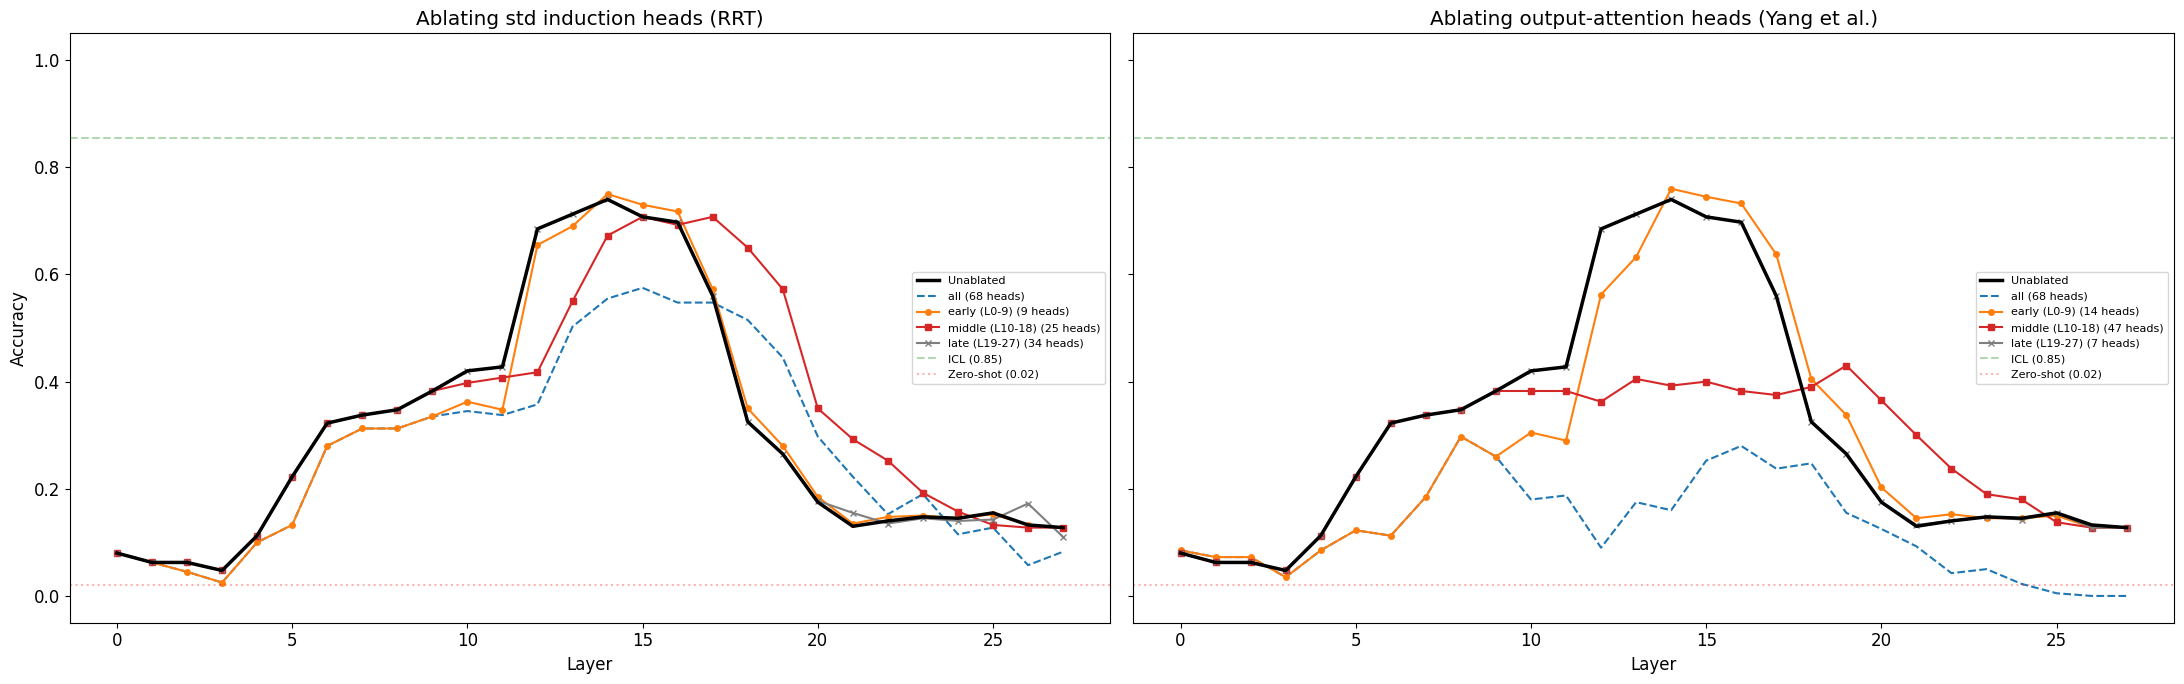

Group                                      Peak acc   Peak layer
Unablated                                     0.740           14
std: all                                      0.575           15
std: early (L0-9)                             0.750           14
std: middle (L10-18)                          0.708           15
std: late (L19-27)                            0.740           14
oattn: all                                    0.297            8
oattn: early (L0-9)                           0.760           14
oattn: middle (L10-18)                        0.430           19
oattn: late (L19-27)                          0.740           14


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
layers = list(range(n_layers))

all_tn = list(all_task_splits.keys())
tv_mean = np.array([[np.mean(patching_acc[tn][l]) for l in layers] for tn in all_tn]).mean(axis=0)
avg_icl = np.mean([np.mean(icl_acc[tn]) for tn in all_tn])
avg_zs = np.mean([np.mean(zs_acc[tn]) for tn in all_tn])

# --- Left panel: std induction ---
ax = axes[0]
ax.plot(layers, tv_mean, 'k-', lw=2.5, label='Unablated', zorder=10)

std_colors = {
    'std: all': 'tab:blue',
    'std: early (L0-9)': 'tab:orange',
    'std: middle (L10-18)': 'tab:red',
    'std: late (L19-27)': 'tab:gray',
}
std_styles = {
    'std: all': '--',
    'std: early (L0-9)': 'o-',
    'std: middle (L10-18)': 's-',
    'std: late (L19-27)': 'x-',
}
for gn in ['std: all', 'std: early (L0-9)', 'std: middle (L10-18)', 'std: late (L19-27)']:
    if gn in ablated_curves:
        n_h = len(ablation_groups[gn])
        label = gn.replace('std: ', '') + f' ({n_h} heads)'
        ax.plot(layers, ablated_curves[gn], std_styles[gn], color=std_colors[gn],
                ms=4, lw=1.5, label=label)

ax.axhline(avg_icl, ls='--', color='green', alpha=0.3, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.3, label=f'Zero-shot ({avg_zs:.2f})')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('Ablating std induction heads (RRT)')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)

# --- Right panel: output attention ---
ax = axes[1]
ax.plot(layers, tv_mean, 'k-', lw=2.5, label='Unablated', zorder=10)

oa_colors = {
    'oattn: all': 'tab:blue',
    'oattn: early (L0-9)': 'tab:orange',
    'oattn: middle (L10-18)': 'tab:red',
    'oattn: late (L19-27)': 'tab:gray',
}
oa_styles = {
    'oattn: all': '--',
    'oattn: early (L0-9)': 'o-',
    'oattn: middle (L10-18)': 's-',
    'oattn: late (L19-27)': 'x-',
}
for gn in ['oattn: all', 'oattn: early (L0-9)', 'oattn: middle (L10-18)', 'oattn: late (L19-27)']:
    if gn in ablated_curves:
        n_h = len(ablation_groups[gn])
        label = gn.replace('oattn: ', '') + f' ({n_h} heads)'
        ax.plot(layers, ablated_curves[gn], oa_styles[gn], color=oa_colors[gn],
                ms=4, lw=1.5, label=label)

ax.axhline(avg_icl, ls='--', color='green', alpha=0.3, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.3, label=f'Zero-shot ({avg_zs:.2f})')
ax.set_xlabel('Layer')
ax.set_title('Ablating output-attention heads (Yang et al.)')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Group':40s} {'Peak acc':>10s} {'Peak layer':>12s}")
print(f"{'Unablated':40s} {max(tv_mean):10.3f} {int(np.argmax(tv_mean)):12d}")
for gn, curve in ablated_curves.items():
    print(f"{gn:40s} {max(curve):10.3f} {int(np.argmax(curve)):12d}")


## Yang et al

In [39]:
# Yang et al. replication with their actual IH selection criterion (Appendix H):
# Top 10% heads by attention from last position to output/label tokens

# Select top 10% by attn_to_output
output_attn_threshold = np.percentile(attn_to_output, 90)
top_output_attn = [(l, h) for l in range(n_layers) for h in range(n_heads)
                   if attn_to_output[l, h] >= output_attn_threshold]
print(f"Top 10% by output attention: {len(top_output_attn)} heads")
print(f"Top 10% by std induction:    {len(top_induction)} heads")
print(f"Overlap: {len(set(top_output_attn) & set(top_induction))} heads")

# Best patching layer per task
best_patch_layer = {}
for task_name in all_task_splits:
    accs = [np.mean(patching_acc[task_name][l]) for l in range(n_layers)]
    best_patch_layer[task_name] = int(np.argmax(accs))

global_best = int(np.argmax([
    np.mean([np.mean(patching_acc[tn][l]) for tn in all_task_splits])
    for l in range(n_layers)
]))

# --- Method 1: Single-layer addition (per-task best layer) ---
ih_acc_single = defaultdict(list)

for task_name, splits in all_task_splits.items():
    if task_name not in mean_head_outputs:
        continue
    mean_z = mean_head_outputs[task_name]
    L_patch = best_patch_layer[task_name]

    vec = np.zeros(d_model)
    for (l, h) in top_output_attn:
        W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
        z_h = mean_z[l, h].numpy()
        vec += W_O.T @ z_h

    tv_tensor = torch.tensor(vec, device=DEVICE, dtype=model.cfg.dtype)

    for eq in splits['eval_data']:
        target = eq['query_output']
        tokens = model.to_tokens(eq['zs_prompt'], prepend_bos=True)

        def add_hook(value, hook, _tv=tv_tensor):
            value[0, -1, :] += _tv
            return value

        with torch.no_grad():
            logits = model.run_with_hooks(tokens,
                fwd_hooks=[(f'blocks.{L_patch}.hook_resid_post', add_hook)])
        ih_acc_single[task_name].append(float(check_correct(model, logits[0, -1], target)))

    print(f"  [single-layer] {task_name}: {np.mean(ih_acc_single[task_name]):.3f}")

# --- Method 2: Per-layer injection at native layers ---
ih_acc_native = defaultdict(list)

for task_name, splits in all_task_splits.items():
    if task_name not in mean_head_outputs:
        continue
    mean_z = mean_head_outputs[task_name]

    ih_hooks = {}
    for (l, h) in top_output_attn:
        W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
        z_h = mean_z[l, h].numpy()
        if l not in ih_hooks:
            ih_hooks[l] = np.zeros(d_model)
        ih_hooks[l] += W_O.T @ z_h

    ih_hooks_t = {l: torch.tensor(v, device=DEVICE, dtype=model.cfg.dtype)
                  for l, v in ih_hooks.items()}

    for eq in tqdm(splits['eval_data'], desc=f"  {task_name}"):
        target = eq['query_output']
        tokens = model.to_tokens(eq['zs_prompt'], prepend_bos=True)

        fwd_hooks = []
        for l, tv in ih_hooks_t.items():
            def make_hook(_tv):
                def hook_fn(value, hook):
                    value[0, -1, :] += _tv
                    return value
                return hook_fn
            fwd_hooks.append((f'blocks.{l}.hook_resid_post', make_hook(tv)))

        with torch.no_grad():
            logits = model.run_with_hooks(tokens, fwd_hooks=fwd_hooks)
        ih_acc_native[task_name].append(float(check_correct(model, logits[0, -1], target)))

    print(f"  [native-layer] {task_name}: {np.mean(ih_acc_native[task_name]):.3f}")

# Summary
tv_baseline = max(np.mean([np.mean(patching_acc[tn][l]) for tn in all_task_splits])
                   for l in range(n_layers))
avg_icl = np.mean([np.mean(icl_acc[tn]) for tn in all_task_splits])
avg_zs = np.mean([np.mean(zs_acc[tn]) for tn in all_task_splits])

print(f"\n{'Method':50s} {'Accuracy':>10s}")
print(f"{'Zero-shot':50s} {avg_zs:10.3f}")
print(f"{'IH (std induction) single-layer per-task':50s} "
      f"{np.mean([np.mean(v) for v in ih_acc_pertask.values()]):10.3f}")
print(f"{'IH (output attn) single-layer per-task':50s} "
      f"{np.mean([np.mean(v) for v in ih_acc_single.values()]):10.3f}")
print(f"{'IH (output attn) native-layer injection':50s} "
      f"{np.mean([np.mean(v) for v in ih_acc_native.values()]):10.3f}")
print(f"{'Full task vector':50s} {tv_baseline:10.3f}")
print(f"{'ICL':50s} {avg_icl:10.3f}")

Top 10% by output attention: 68 heads
Top 10% by std induction:    68 heads
Overlap: 28 heads


  [single-layer] knowledge/country_capital: 0.700
  [single-layer] knowledge/football_player_position: 0.200
  [single-layer] knowledge/location_continent: 0.150
  [single-layer] knowledge/location_country: 0.700
  [single-layer] knowledge/location_language: 0.800
  [single-layer] knowledge/location_religion: 0.250
  [single-layer] knowledge/person_language: 0.800
  [single-layer] knowledge/person_profession: 0.400
  [single-layer] linguistic/antonyms: 0.800
  [single-layer] linguistic/plural_singular: 1.000
  [single-layer] linguistic/present_simple_gerund: 1.000
  [single-layer] linguistic/present_simple_past_perfect: 1.000
  [single-layer] linguistic/present_simple_past_simple: 1.000
  [single-layer] linguistic/singular_plural: 1.000
  [single-layer] translation/en_es: 0.800
  [single-layer] translation/en_fr: 0.850
  [single-layer] translation/en_it: 0.400
  [single-layer] translation/es_en: 0.700
  [single-layer] translation/fr_en: 0.700
  [single-layer] translation/it_en: 0.750


  knowledge/country_capital: 100%|██████████| 20/20 [00:00<00:00, 24.44it/s]


  [native-layer] knowledge/country_capital: 0.800


  knowledge/football_player_position: 100%|██████████| 20/20 [00:00<00:00, 24.30it/s]


...

  [native-layer] translation/es_en: 0.800


  translation/fr_en: 100%|██████████| 20/20 [00:00<00:00, 24.40it/s]


  [native-layer] translation/fr_en: 0.700


  translation/it_en: 100%|██████████| 20/20 [00:00<00:00, 24.33it/s]

  [native-layer] translation/it_en: 0.800

Method                                               Accuracy
Zero-shot                                               0.020
IH (std induction) single-layer per-task                0.395
IH (output attn) single-layer per-task                  0.700
IH (output attn) native-layer injection                 0.800
Full task vector                                        0.740
ICL                                                     0.855
